In [1]:
import sys
sys.path.append('/Users/benny/Repos/octagon_analysis')

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
from parse_data import prepare_data
from parse_data import identify_filepaths
import globals
from plotting import plot_trajectory, plot_octagon

from data_extraction import get_indices
import seaborn as sns

from analysis import heatmap_phigh
import time
from data_extraction import extract_trial
import pandas as pd
from trajectory_analysis import trajectory_headangle, trajectory_vectors
from analysis import wall_visibility_and_choice
import matplotlib.pyplot as plt


In [31]:
data_folder = '/Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs'
solo_files = identify_filepaths.get_relative_paths('Solo', data_folder)

df_solo, trial_lists_solo = prepare_data.prepare_data(data_folder, solo_files, combine=False)

dfs = df_solo
trial_lists = trial_lists_solo
num_players = 1

IntProgress(value=0, max=43)

filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260416_1/2026-04-29_13-30-52_M18_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_1/2026-04-29_11-42-49_M19_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_2/2026-04-29_08-18-54_M20_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_3/2026-04-29_06-54-23_M21_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_4/2026-04-28_19-57-43_M22_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260418_1/2026-04-28_18-35-32_M23_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/da

In [32]:
dropped_trials = 1

In [33]:
dfs_cropped = []
for i in range(len(dfs)):
    df = dfs[i]
    mask = df['eventDescription'] == 'trial end'
    if mask.any():
        first_end_idx = df.index[mask][0]
        print(f"First trial end event found at index: {first_end_idx}")
        df = df.loc[first_end_idx + 1:]
    dfs_cropped.append(df)

First trial end event found at index: 539
First trial end event found at index: 545
First trial end event found at index: 539
First trial end event found at index: 555
First trial end event found at index: 556
First trial end event found at index: 557
First trial end event found at index: 553
First trial end event found at index: 547
First trial end event found at index: 576
First trial end event found at index: 547
First trial end event found at index: 518
First trial end event found at index: 519
First trial end event found at index: 545
First trial end event found at index: 553
First trial end event found at index: 578
First trial end event found at index: 546
First trial end event found at index: 533
First trial end event found at index: 588
First trial end event found at index: 621
First trial end event found at index: 538
First trial end event found at index: 538
First trial end event found at index: 655
First trial end event found at index: 588
First trial end event found at ind

In [34]:
trial_lists = [trial_list[dropped_trials:] for trial_list in trial_lists]

**CURRENT PLAN**

1. Plot session trajectories for each file

2. P(H) across walls

2. High choices across octagon space with first seen

3. Centrality (I guess probably visible from session trajectories)

4. Relate to parameters


### Parameter value extraction

In [35]:
import agent_analysis.functions.preprocessing as prep

In [36]:
_, step_penalties = prep.extract_step_penalties(data_folder, yaml_filename=None)

In [37]:
len(step_penalties)

43

## Session trajectories

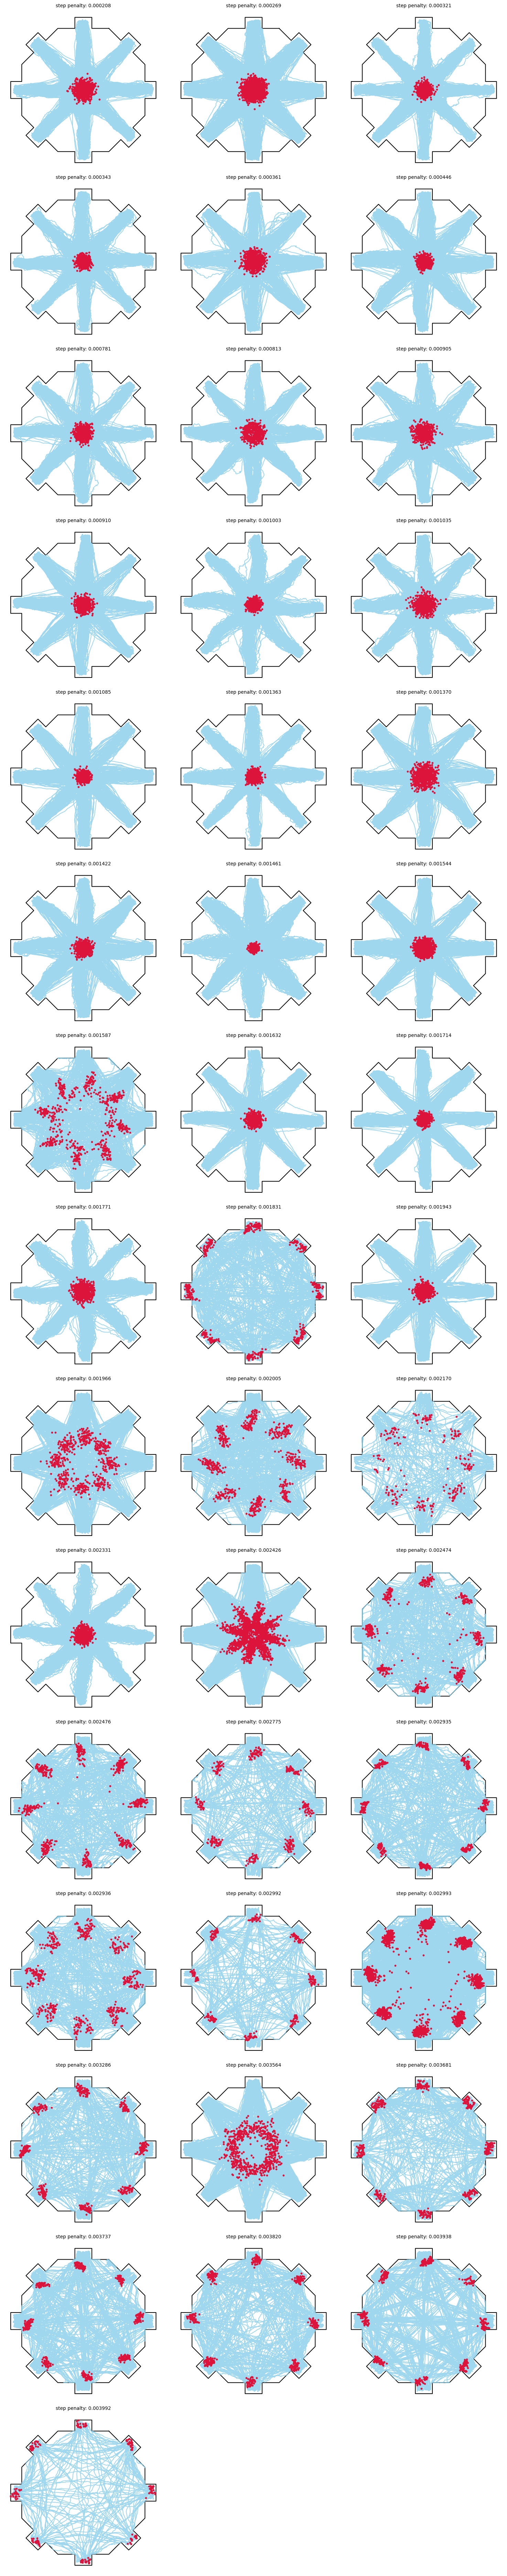

In [38]:
import matplotlib.pyplot as plt

num_lists = len(dfs_cropped)
num_cols = 3
num_rows = (num_lists + num_cols - 1) // num_cols
fig, axes = plt.subplots(num_rows, num_cols, figsize=(5*num_cols, 5*num_rows))

axes = axes.flatten()

# Create list of (penalty, trial_list) and sort by penalty
sorted_trials = sorted(zip(step_penalties, dfs_cropped), key=lambda x: x[0])

for i, (penalty, trial_list) in enumerate(sorted_trials):
    ax = plot_octagon.plot_octagon(ax=axes[i])
    plot_trajectory.plot_session_trajectory(ax, trial_list, colour_player_1='skyblue', alpha=0.8, slice_onset_markers=True)
    plot_trajectory.mark_session_slice_onsets(ax, trial_list, chosen_player=0, color='crimson')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_title(f'step penalty: {penalty:.6f}', fontsize=10)

for j in range(num_lists, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## P(High) across walls

In [85]:
solo_example = [trial_lists_solo[25]]

In [75]:
analysis_results = {
    session_id: {

            # trial list and filtered trial indices
            'trial_lists': {
                'full_session': None
            },

            # chosen wall numbers and whether high or low
            'choice_data' : {
                'wall_numbers': None,
                'chose_high': None,
                'probability_chose_high': None  # array of values from walls 1 to 8
            }
            

        }
    #for session_id in np.arange(len(trial_lists))
    for session_id in np.arange(len(solo_example))
}

In [76]:
print(np.arange(len(trial_lists)))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]


In [77]:
for session_id in analysis_results.keys():

    print(f"\n\nProcessing session: {session_id}\n\n")
    player_data = analysis_results[session_id]
    #trial_list = trial_lists[session_id]
    trial_list = solo_example[session_id]
    print(f"Number of trials in full session: {len(trial_list)}")


    player_data['trial_lists']['full_session'] = trial_list



Processing session: 0


Number of trials in full session: 668


In [78]:
for session_id in analysis_results.keys():
    
    player_data = analysis_results[session_id]
    trial_list = player_data['trial_lists']['full_session']
    print(session_id)

    player_data['choice_data']['wall_numbers'] = get_indices.get_chosen_walls(trial_list).astype(int)
    player_data['choice_data']['chose_high'] = get_indices.was_high_wall_chosen(trial_list)


    # print(len(player_data['choice_data']['chose_high']))

0


In [79]:
for session_id in analysis_results.keys():
    
    player_data = analysis_results[session_id]
    wall_numbers = player_data['choice_data']['wall_numbers']
    chose_high = player_data['choice_data']['chose_high']

    wall_probabilities = np.full(8, np.nan)

    # specify min bins == highest integer value + 1
    # slice from index 1 because 0 will always be counted, but is not relevant
    counts = np.bincount(wall_numbers, minlength=9)[1:]  # count occurrences of 1-8
    chosen_counts = np.bincount(wall_numbers[chose_high], minlength=9)[1:]  # count True occurrences

    mask = counts > 0  # Avoid division by zero
    mask = counts > 4  # Ensure at least 5 trials per wall to calculate probability
    wall_probabilities[mask] = chosen_counts[mask] / counts[mask]

    player_data['choice_data']['probability_chose_high'] = wall_probabilities

In [80]:
wall_number_list = [analysis_results[session_id]['choice_data']['wall_numbers']
 for session_id in analysis_results
 ]
chose_high_list = [analysis_results[session_id]['choice_data']['chose_high']
 for session_id in analysis_results
 ]


wall_numbers = np.concatenate(wall_number_list).astype(int)
chose_high = np.concatenate(chose_high_list)

In [81]:
# more efficient code with vectorised functions

wall_probabilities = np.full(8, np.nan)

# specify min bins == highest integer value + 1
# slice from index 1 because 0 will always be counted, but is not relevant
counts = np.bincount(wall_numbers, minlength=9)[1:]  # count occurrences of 1-8
chosen_counts = np.bincount(wall_numbers[chose_high], minlength=9)[1:]  # count True occurrences

mask = counts > 0  # Avoid division by zero
wall_probabilities[mask] = chosen_counts[mask] / counts[mask]

In [82]:
# get error bars

standard_error = np.sqrt((wall_probabilities * (1 - wall_probabilities)) / len(wall_number_list))

### example model

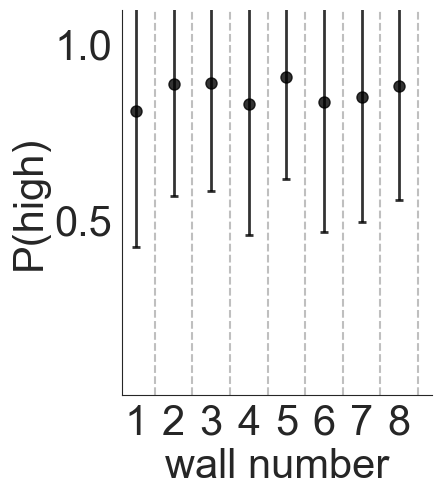

In [84]:
wall_numbers = np.arange(1,9)
wall_probabilities = wall_probabilities

# set seaborn style
sns.set_style("white", {"axes.grid": False})

# create figure and axis
plt.figure(figsize=(4, 5))

# plot vertical dashed grey lines for each categorical x value
for x in wall_numbers:
    plt.axvline(x=x+0.5, color='grey', linestyle='dashed', alpha=0.5)

# plot the probability line with markers
#sns.lineplot(x=wall_numbers, y=wall_probabilities, marker='o', markersize=8, linewidth=2.5, color="black")
#plt.errorbar(x=wall_numbers, y=wall_probabilities, yerr=standard_error, fmt="o")
plt.errorbar(
    wall_numbers,
    wall_probabilities,
    yerr=standard_error,
    fmt='o',
    alpha=0.8,
    color="black",
    markersize=8,

    ecolor='black',            
    elinewidth=2,              
    capsize=3,                 
    capthick=2,

    linestyle='none'
)
# Customize labels and title
plt.xlabel("wall number", fontsize=30)
plt.ylabel("P(high)", fontsize=30)
# plt.title("Probability of Choosing High by Wall Number", fontsize=14)

# set y-axis for probability
plt.ylim([0,1.1])

# adjust x-axis ticks to match categorical values
plt.xticks(wall_numbers, fontsize=30)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=30)

ax = plt.gca()
ax.get_yticklabels()[0].set_visible(False)

# Remove top and right borders
sns.despine(top=True, right=True)

# show the plot
plt.show()

### Across models

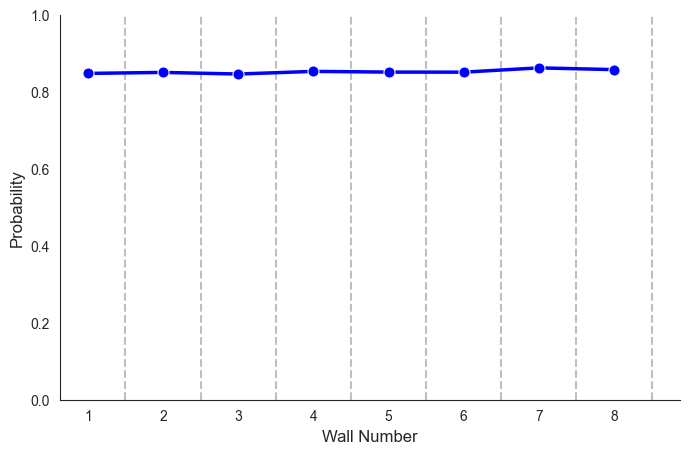

In [47]:
wall_numbers = np.arange(1,9)
wall_probabilities = wall_probabilities

# set seaborn style
sns.set_style("white", {"axes.grid": False})

# create figure and axis
plt.figure(figsize=(8, 5))

# plot vertical dashed grey lines for each categorical x value
for x in wall_numbers:
    plt.axvline(x=x+0.5, color='grey', linestyle='dashed', alpha=0.5)

# plot the probability line with markers
sns.lineplot(x=wall_numbers, y=wall_probabilities, marker='o', markersize=8, linewidth=2.5, color="b")

# Customize labels and title
plt.xlabel("Wall Number", fontsize=12)
plt.ylabel("Probability", fontsize=12)
# plt.title("Probability of Choosing High by Wall Number", fontsize=14)

# set y-axis for probability
plt.ylim([0,1])

# adjust x-axis ticks to match categorical values
plt.xticks(wall_numbers)

# Remove top and right borders
sns.despine(top=True, right=True)

# show the plot
plt.show()

### By step penalty

In [48]:
sorted_sessions = sorted(zip(step_penalties, analysis_results.keys()), key=lambda x: x[0])

In [441]:
print(list(analysis_results.keys()))
print([analysis_results[i]['choice_data']['probability_chose_high'] for i in analysis_results.keys()])

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]
[array([0.87341772, 0.87058824, 0.9       , 0.88888889, 0.86170213,
       0.88461538, 0.84415584, 0.80722892]), array([0.82608696, 0.78823529, 0.72222222, 0.71428571, 0.8245614 ,
       0.7260274 , 0.85507246, 0.77922078]), array([1., 1., 1., 1., 1., 1., 1., 1.]), array([0.70967742, 0.69565217, 0.875     , 0.74358974, 0.65625   ,
       0.84375   , 0.6875    , 0.93939394]), array([1.        , 0.98979592, 0.97727273, 1.        , 0.98734177,
       0.98630137, 1.        , 0.98717949]), array([0.87804878, 0.90384615, 0.88235294, 0.83146067, 0.90789474,
       0.83783784, 0.87777778, 0.91549296]), array([0.89552239, 0.87096774, 0.92045455, 0.82608696, 0.89189189,
       0.93421053, 0.86363636, 0.85869565]), array([0.81609195, 0.89411765, 0.90909091, 

Average P(High) for session 19 (step penalty: 0.000208): 1.000
Average P(High) for session 11 (step penalty: 0.000269): 0.872
Average P(High) for session 28 (step penalty: 0.000321): 0.985
Average P(High) for session 27 (step penalty: 0.000343): 0.883
Average P(High) for session 23 (step penalty: 0.000361): 0.882
Average P(High) for session 24 (step penalty: 0.000446): 0.874
Average P(High) for session 31 (step penalty: 0.000781): 0.878
Average P(High) for session 8 (step penalty: 0.000813): 0.996
Average P(High) for session 7 (step penalty: 0.000905): 0.887
Average P(High) for session 5 (step penalty: 0.000910): 0.883
Average P(High) for session 21 (step penalty: 0.001003): 0.991
Average P(High) for session 36 (step penalty: 0.001035): 0.924
Average P(High) for session 15 (step penalty: 0.001085): 0.846
Average P(High) for session 25 (step penalty: 0.001363): 0.861
Average P(High) for session 26 (step penalty: 0.001370): 0.878
Average P(High) for session 22 (step penalty: 0.001422): 0

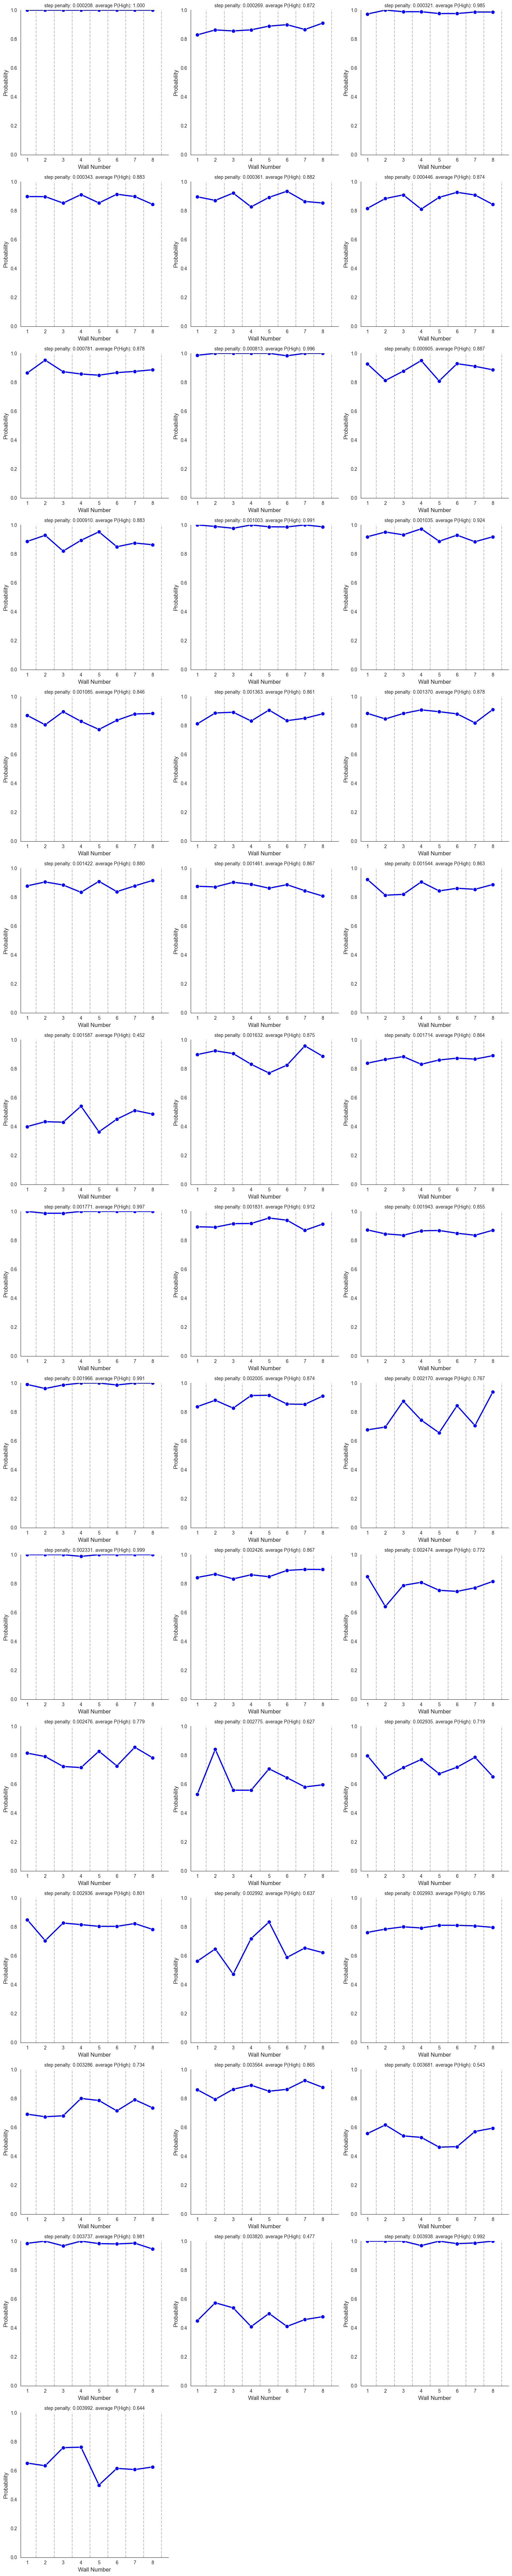

In [49]:
num_sessions = len(analysis_results)
num_cols = 3
num_rows = (num_sessions + num_cols - 1) // num_cols  # ceiling division
fig, axes = plt.subplots(num_rows, num_cols, figsize=(5*num_cols, 5*num_rows))

axes = axes.flatten()

# Create list of (penalty, session_id) and sort by penalty
sorted_sessions = sorted(zip(step_penalties, analysis_results.keys()), key=lambda x: x[0])

for i, (penalty, session_id) in enumerate(sorted_sessions):
    ax = axes[i]
    
    wall_number_list = [analysis_results[session_id]['choice_data']['wall_numbers']]
    chose_high_list = [analysis_results[session_id]['choice_data']['chose_high']]

    wall_numbers = np.concatenate(wall_number_list).astype(int)
    chose_high = np.concatenate(chose_high_list)

    wall_probabilities = np.full(8, np.nan)

    # specify min bins == highest integer value + 1
    # slice from index 1 because 0 will always be counted, but is not relevant
    counts = np.bincount(wall_numbers, minlength=9)[1:]  # count occurrences of 1-8
    chosen_counts = np.bincount(wall_numbers[chose_high], minlength=9)[1:]  # count True occurrences

    mask = counts > 0  # Avoid division by zero
    wall_probabilities[mask] = chosen_counts[mask] / counts[mask]

    # Print average P(High) across walls for each session
    avg_p_high = np.nanmean(wall_probabilities)
    print(f"Average P(High) for session {session_id} (step penalty: {penalty:.6f}): {avg_p_high:.3f}")

    wall_numbers_plot = np.arange(1,9)
    
    # set seaborn style
    sns.set_style("white", {"axes.grid": False})

    # plot vertical dashed grey lines for each categorical x value
    for x in wall_numbers_plot:
        ax.axvline(x=x+0.5, color='grey', linestyle='dashed', alpha=0.5)

    # plot the probability line with markers
    sns.lineplot(x=wall_numbers_plot, y=wall_probabilities, marker='o', markersize=8, linewidth=2.5, color="b", ax=ax)

    # Customize labels and title
    ax.set_xlabel("Wall Number", fontsize=12)
    ax.set_ylabel("Probability", fontsize=12)
    ax.set_title(f'step penalty: {penalty:.6f}. average P(High): {avg_p_high:.3f}', fontsize=10)

    # set y-axis for probability
    ax.set_ylim([0,1])

    # adjust x-axis ticks to match categorical values
    ax.set_xticks(wall_numbers_plot)

    # Remove top and right borders
    sns.despine(ax=ax, top=True, right=True)

for j in range(num_sessions, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Average P(High) for session 2 (step penalty: 0.000208): 1.000
Average P(High) for session 11 (step penalty: 0.000321): 0.984
Average P(High) for session 10 (step penalty: 0.000343): 0.883
Average P(High) for session 6 (step penalty: 0.000361): 0.883
Average P(High) for session 7 (step penalty: 0.000446): 0.876
Average P(High) for session 14 (step penalty: 0.000781): 0.877
Average P(High) for session 4 (step penalty: 0.001003): 0.991
Average P(High) for session 8 (step penalty: 0.001363): 0.864
Average P(High) for session 9 (step penalty: 0.001370): 0.879
Average P(High) for session 5 (step penalty: 0.001422): 0.879
Average P(High) for session 0 (step penalty: 0.001461): 0.866
Average P(High) for session 15 (step penalty: 0.002005): 0.875
Average P(High) for session 3 (step penalty: 0.002170): 0.769
Average P(High) for session 16 (step penalty: 0.002331): 0.999
Average P(High) for session 1 (step penalty: 0.002476): 0.779
Average P(High) for session 17 (step penalty: 0.002992): 0.634
Av

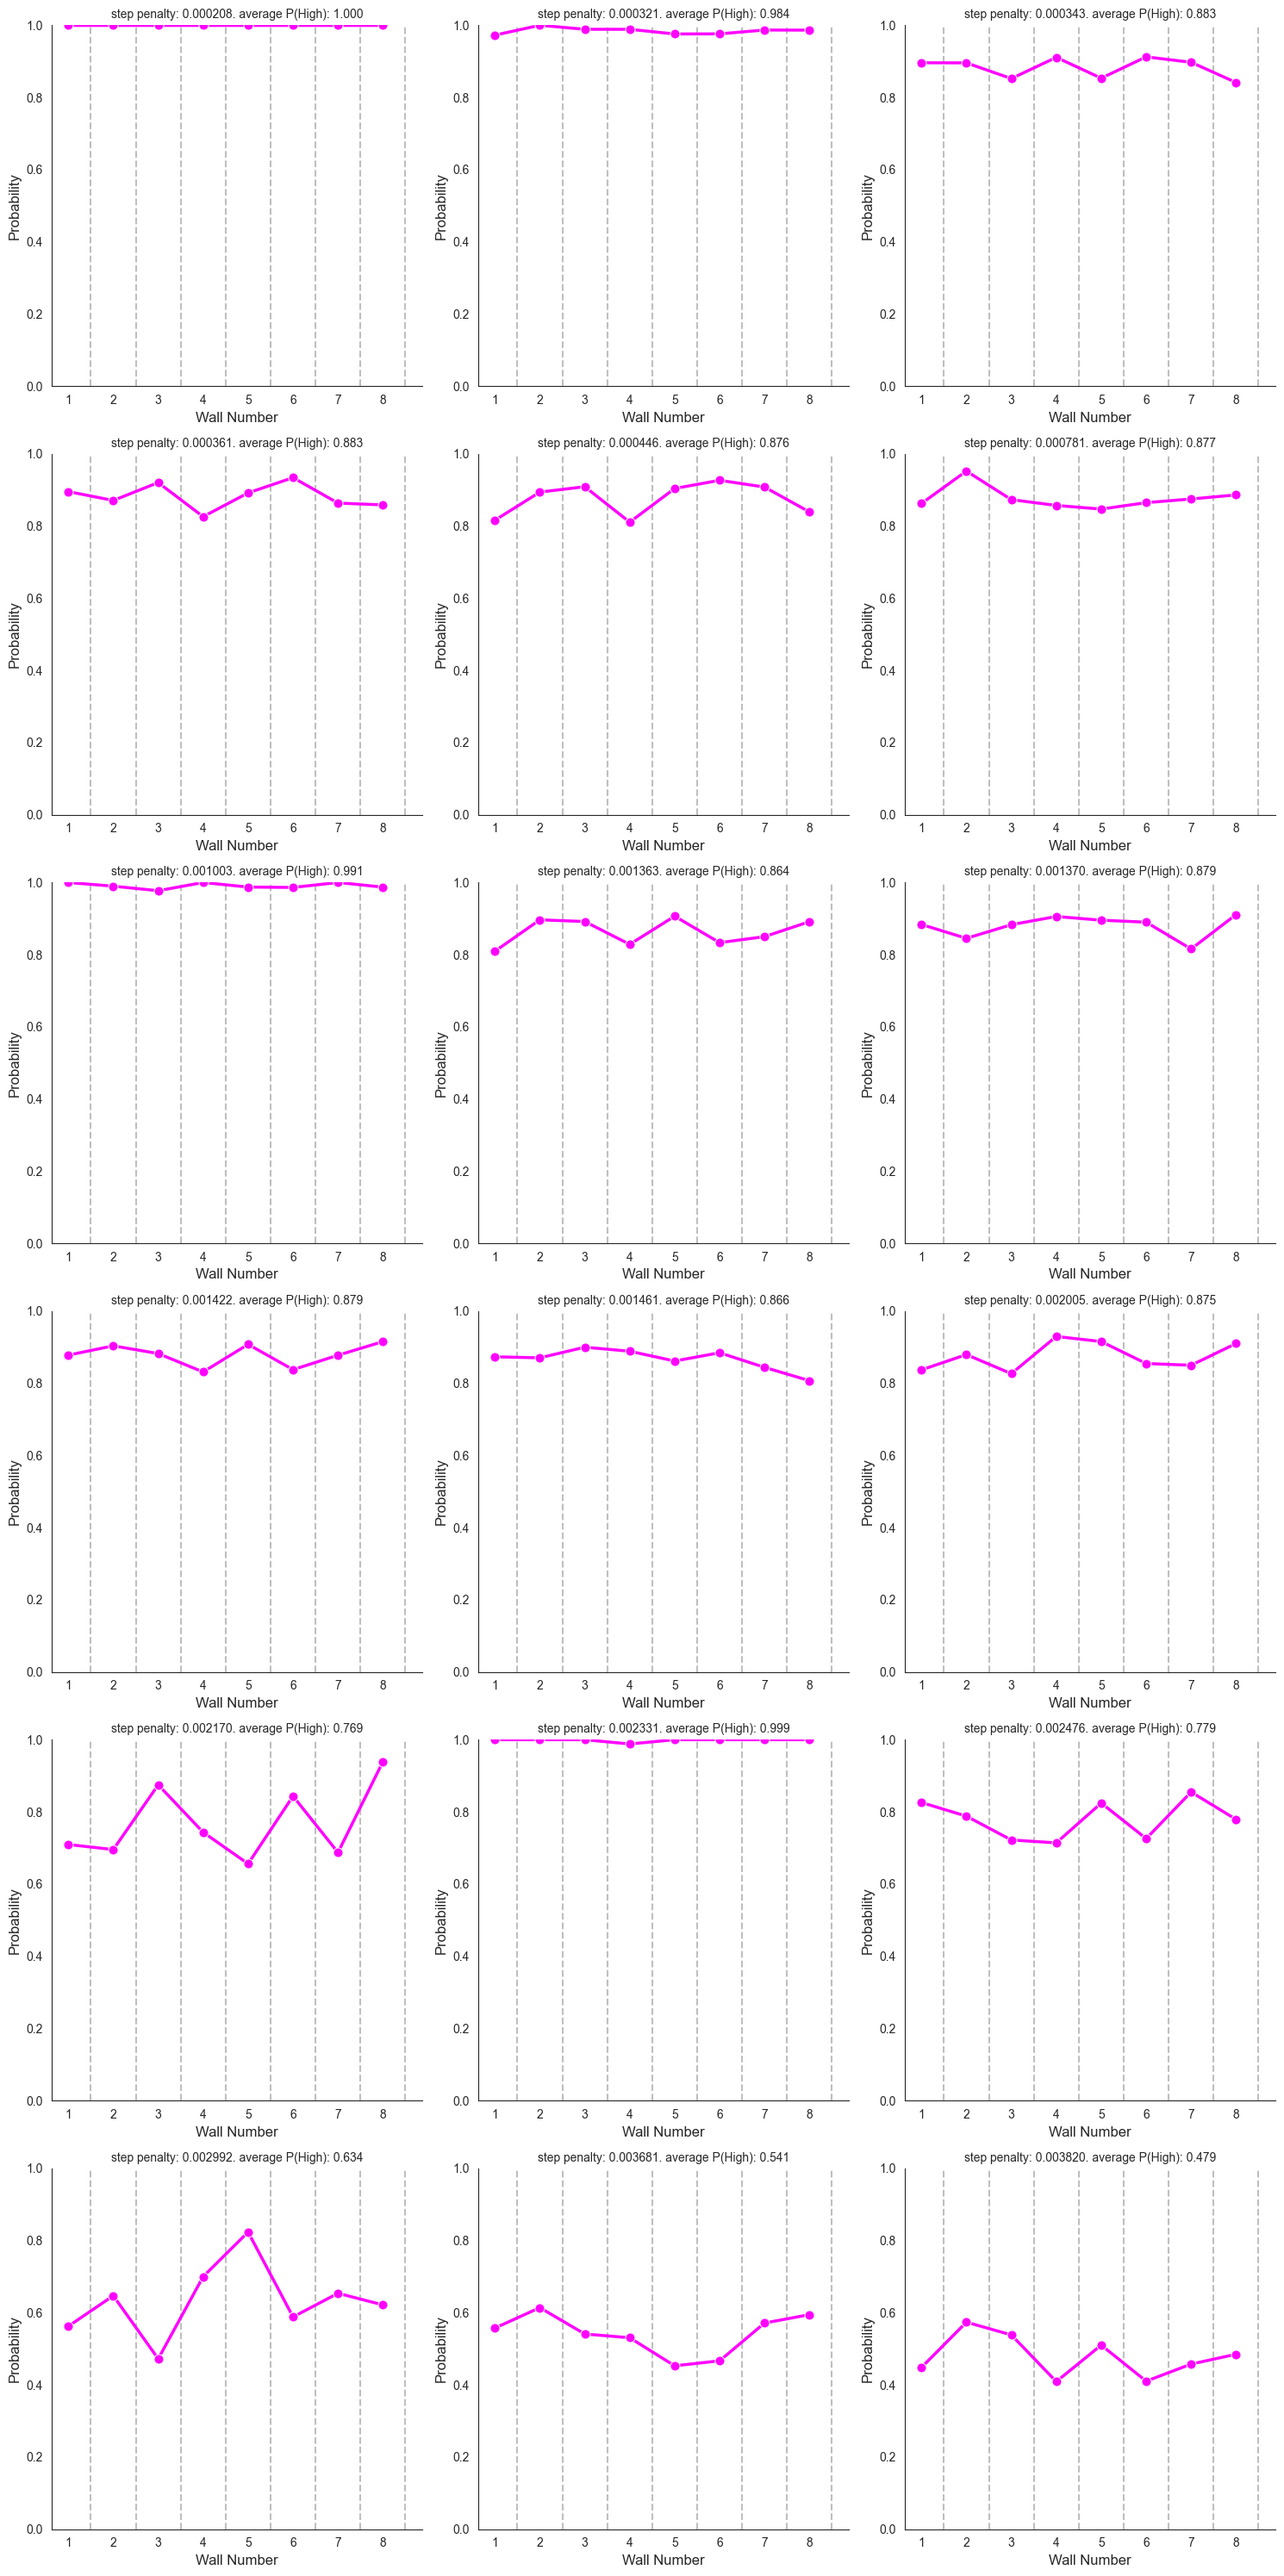

In [443]:
num_sessions = len(analysis_results)
num_cols = 3
num_rows = (num_sessions + num_cols - 1) // num_cols  # ceiling division
fig, axes = plt.subplots(num_rows, num_cols, figsize=(5*num_cols, 5*num_rows))

axes = axes.flatten()

# Create list of (penalty, session_id) and sort by penalty
sorted_sessions = sorted(zip(step_penalties, analysis_results.keys()), key=lambda x: x[0])

for i, (penalty, session_id) in enumerate(sorted_sessions):
    ax = axes[i]
    
    wall_number_list = [analysis_results[session_id]['choice_data']['wall_numbers']]
    chose_high_list = [analysis_results[session_id]['choice_data']['chose_high']]

    wall_numbers = np.concatenate(wall_number_list).astype(int)
    chose_high = np.concatenate(chose_high_list)

    wall_probabilities = np.full(8, np.nan)

    # specify min bins == highest integer value + 1
    # slice from index 1 because 0 will always be counted, but is not relevant
    counts = np.bincount(wall_numbers, minlength=9)[1:]  # count occurrences of 1-8
    chosen_counts = np.bincount(wall_numbers[chose_high], minlength=9)[1:]  # count True occurrences

    mask = counts > 0  # Avoid division by zero
    wall_probabilities[mask] = chosen_counts[mask] / counts[mask]

    # Print average P(High) across walls for each session
    avg_p_high = np.nanmean(wall_probabilities)
    print(f"Average P(High) for session {session_id} (step penalty: {penalty:.6f}): {avg_p_high:.3f}")

    wall_numbers_plot = np.arange(1,9)
    
    # set seaborn style
    sns.set_style("white", {"axes.grid": False})

    # plot vertical dashed grey lines for each categorical x value
    for x in wall_numbers_plot:
        ax.axvline(x=x+0.5, color='grey', linestyle='dashed', alpha=0.5)

    # plot the probability line with markers
    sns.lineplot(x=wall_numbers_plot, y=wall_probabilities, marker='o', markersize=8, linewidth=2.5, color="magenta", ax=ax)

    # Customize labels and title
    ax.set_xlabel("Wall Number", fontsize=12)
    ax.set_ylabel("Probability", fontsize=12)
    ax.set_title(f'step penalty: {penalty:.6f}. average P(High): {avg_p_high:.3f}', fontsize=10)

    # set y-axis for probability
    ax.set_ylim([0,1])

    # adjust x-axis ticks to match categorical values
    ax.set_xticks(wall_numbers_plot)

    # Remove top and right borders
    sns.despine(ax=ax, top=True, right=True)

for j in range(num_sessions, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### P(H) by step penalty

In [327]:
len(avg_p_high_list)

45

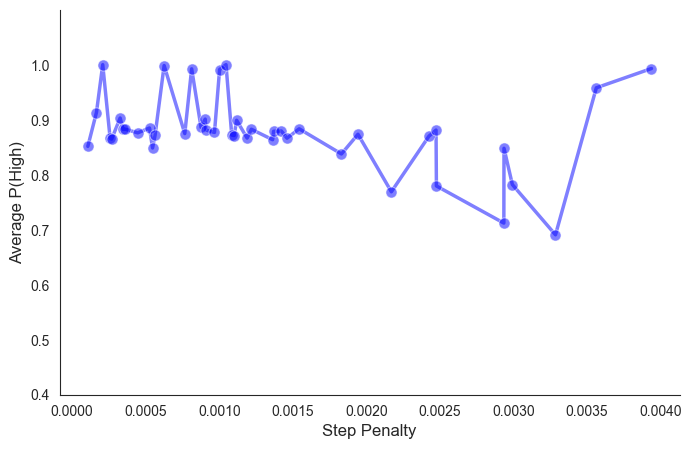

In [328]:
# Collect average P(High) for each session, sorted by step penalty
avg_p_high_list = []
sorted_penalties = []

for penalty, session_id in sorted(zip(step_penalties, analysis_results.keys()), key=lambda x: x[0]):
    if session_id in [17, 23]:  # Exclude sessions 17 and 23
        continue
    wall_probabilities = analysis_results[session_id]['choice_data']['probability_chose_high']
    avg_p_high = np.nanmean(wall_probabilities)
    sorted_penalties.append(penalty)
    avg_p_high_list.append(avg_p_high)

# Plot the line graph
plt.figure(figsize=(8, 5))
sns.lineplot(x=sorted_penalties, y=avg_p_high_list, marker='o', markersize=8, linewidth=2.5, alpha=0.5, color="b")
plt.xlabel("Step Penalty", fontsize=12)
plt.ylabel("Average P(High)", fontsize=12)
plt.ylim([0.7, 1.1])
plt.yticks(np.arange(0.4, 1.1, 0.1))
sns.despine(top=True, right=True)
plt.show()

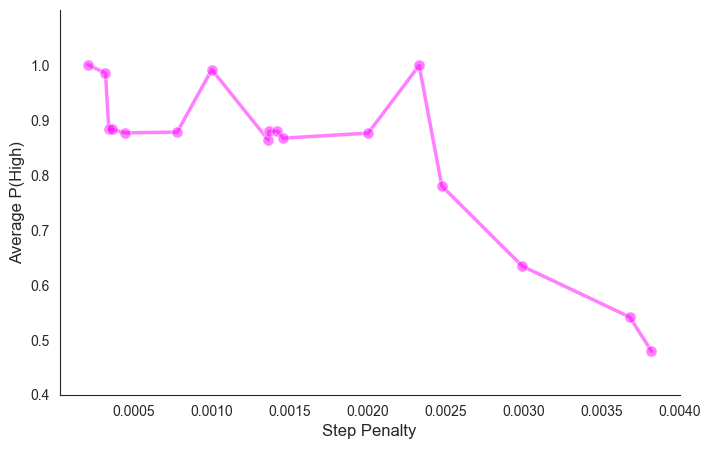

In [445]:
# Collect average P(High) for each session, sorted by step penalty
avg_p_high_list = []
sorted_penalties = []

for penalty, session_id in sorted(zip(step_penalties, analysis_results.keys()), key=lambda x: x[0]):
    if session_id in [3]:  
        continue
    wall_probabilities = analysis_results[session_id]['choice_data']['probability_chose_high']
    avg_p_high = np.nanmean(wall_probabilities)
    sorted_penalties.append(penalty)
    avg_p_high_list.append(avg_p_high)

# Plot the line graph
plt.figure(figsize=(8, 5))
sns.lineplot(x=sorted_penalties, y=avg_p_high_list, marker='o', markersize=8, linewidth=2.5, alpha=0.5, color="magenta")
plt.xlabel("Step Penalty", fontsize=12)
plt.ylabel("Average P(High)", fontsize=12)
plt.ylim([0.7, 1.1])
plt.yticks(np.arange(0.4, 1.1, 0.1))
sns.despine(top=True, right=True)
plt.show()

## P(High) by first-seen wall

### NOTE: I am reprocessing the heatmaps with the models with consistent seed and fuller logs. Excluding session 3 from this because it shows weird wall biases.

In [357]:
data_folder = '/Users/benny/Desktop/agents_seed_17_full_logs'
solo_files = identify_filepaths.get_relative_paths('Solo', data_folder)

df_solo, trial_lists_solo = prepare_data.prepare_data(data_folder, solo_files, combine=False)

df = df_solo
trial_lists = trial_lists_solo
num_players = 1

IntProgress(value=0, max=10)

filepath: /Users/benny/Desktop/agents_seed_17_full_logs/260421_3/2026-04-21_20-08-13_M36_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Desktop/agents_seed_17_full_logs/260422_1/2026-04-22_02-34-41_M37_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Desktop/agents_seed_17_full_logs/260422_2/2026-04-22_09-01-27_M38_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Desktop/agents_seed_17_full_logs/260422_3/2026-04-22_14-56-20_M39_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Desktop/agents_seed_17_full_logs/260422_4/2026-04-22_22-16-02_M40_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Desktop/agents_seed_17_full_logs/260423_1/2026-04-23_04-03-01_M41_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Desktop/agents_seed_17_full_logs/260423_2/2026-04-23_09-52-14_M42_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Us

Functions are here copied, pasted, and modified so that short trials do not return nan.

In [333]:
def head_angle_to_closest_wall_section_throughout_trajectory(trial_list=None, trial_index=0, trial=None, player_id=0,
                                                             window_size=5, num_walls=8, debug=False):
    ''' From a trajectory, calculate the angles between the player head angle vector and 
        the player-to-closest-wall-coordinate vectors for an entire trial
        Returns an array of shape num_walls*timepoints '''

    # access the dataframe for the trial
    trial = extract_trial.extract_trial(trial, trial_list, trial_index)

    # get the trajectory for calculating direction vectors to alcoves
    trajectory = trajectory_vectors.extract_trial_player_trajectory(trial=trial, player_id=player_id)

    # find head angle unit vectors for a player at each timepoint, smoothed with a rolling window
    trial_player_headangles = trajectory_vectors.extract_trial_player_headangles(trial=trial, player_id=player_id)
    smoothed_head_angle_vectors = trajectory_headangle.get_smoothed_player_head_angle_vectors_for_trial(trial_player_headangles,
                                                                         window_size=window_size)

    
    if debug:
        print("smoothed_player_head_angles.shape: ", smoothed_head_angle_vectors.shape)

    # find the closest (angular) wall coordinates for each wall and timepoint
    wall_coords_cross_product_dependent = trajectory_headangle.get_wall_coords_cross_product_dependent(trial=trial, player_id=player_id, window_size=window_size)

    # find the player-to-closest-wall-coordinate vectors for each wall, for each timepoint
    player_to_closest_wall_section = trajectory_headangle.get_player_to_closest_wall_section_direction_vectors_for_trajectory(trajectory,
                                                                                                     wall_coords_cross_product_dependent,    
                                                                                                     num_walls=num_walls)
    
    if debug:
        print("player_to_closest_wall_section.shape: ", player_to_closest_wall_section.shape)
    
    # calculate the dot products between the closest-wall-section and player-headangle vectors (for each wall, timepoint)
    dot_products_trajectory = trajectory_vectors.calculate_vector_dot_products_for_trajectory(player_to_closest_wall_section,
                                                                                   smoothed_head_angle_vectors,
                                                                                   num_walls=num_walls)

    if debug:
        print("dot_products_trajectory.shape: ", dot_products_trajectory.shape)


    
    # calculate the norms for the closest-wall-section and player-headangle vectors (for each wall, timepoint)
    (head_angle_vector_norms_trajectory,
     player_to_closest_wall_section_vector_norms_trajectory) = trajectory_vectors.calculate_vector_norms_for_trajectory(player_to_closest_wall_section,
                                                                                                   smoothed_head_angle_vectors,
                                                                                                   num_walls=8)
    if debug:
        
        print("head_angle_vector_norms_trajectory.shape: ", head_angle_vector_norms_trajectory.shape)
        print("player_to_closest_wall_section_vector_norms_trajectory.shape: ", player_to_closest_wall_section_vector_norms_trajectory.shape)

    # calculate cosine similarity for the closest-wall-section and player-headangle vectors (for each wall, timepoint)
    cosine_similairities_trajectory = trajectory_vectors.calculate_cosine_similarity_for_trajectory(dot_products_trajectory,
                                                                                             head_angle_vector_norms_trajectory,
                                                                                             player_to_closest_wall_section_vector_norms_trajectory,
                                                                                             num_walls=8)

    if debug:
        print("cosine_similairities_trajectory.shape: ", cosine_similairities_trajectory.shape)

    # calculate angles between player head direction and player-to-alcove vectors for each wall
    thetas = trajectory_vectors.calculate_thetas_for_trajectory(cosine_similairities_trajectory, num_walls=8)

    return thetas
    

In [334]:
def get_wall_visible(trial_list=None, trial_index=0, trial=None, player_id=0, current_fov=110.36, window_size=5, debug=False):
    ''' Returns wall visibility array (boolean array of whether each wall is visible for
        the player at each timepoint, shape num_walls*timepoints), for a chosen player and 
        chosen trial '''
    
    if debug:
        start_time = time.time()
    


    # access the dataframe for the trial
    trial = extract_trial.extract_trial(trial, trial_list, trial_index)    

    
    if debug:
        print(f"get_wall_visible trial is of type {type(trial)}")
        if isinstance(trial, int):
            print(f"get_wall_visible int trials is: {trial}")
    assert isinstance(trial, pd.DataFrame), f"trial is of type {type(trial)}, not pd.DataFrame"

    # trajectory = trajectory_vectors.extract_trial_player_trajectory(trial=trial, player_id=player_id)
    # head_angle_vector_array_trial = trajectory_vectors.extract_trial_player_headangles(trial=trial, player_id=player_id)
    # trial_player_headangles = get_smoothed_player_head_angle_vectors_for_trial(head_angle_vector_array_trial)

    # wall_coords_cross_product_dependent = get_wall_coords_cross_product_dependent(trial=trial, player_id=player_id)

    # thetas = head_angle_to_closest_wall_section_throughout_trajectory(trajectory,
    #                                                                   trial_player_headangles,
    #                                                                   wall_coords_cross_product_dependent)

    thetas = head_angle_to_closest_wall_section_throughout_trajectory(trial=trial, player_id=player_id, window_size=window_size)

    if isinstance(thetas, float) and np.isnan(thetas):
        if debug:
            print(f"trial is too short to analyse. Returning np.nan instead of wall_visible array")
        return np.nan
    
    thetas = np.rad2deg(thetas)

    wall_visible = thetas < current_fov/2

    # output the time taken for this function
    if debug:
        end_time = time.time()
        print(f"Time taken for get_wall_visible (one trial, one player) is {end_time-start_time:.2f}")


    return wall_visible

In [335]:
def get_given_wall_first_visible_session(trial_list, player_id, wall_index, current_fov, window_size, debug=False):
    ''' Return a len(trial_list) truth array for whether the wall wall_index (e.g. wall_1 has an index value of 0)
        became visible first on a trial for the player player_id. '''    

    # # get wall initial visibility for a full session
    # (wall1_initially_visible_session,
    # wall2_initially_visible_session) = get_walls_initial_visibility_session(trial_list,
    #                                                                         player_id, current_fov,
    #                                                                         debug=False)
    # wall_initial_visibility = np.vstack([wall1_initially_visible_session, wall2_initially_visible_session])
    # if debug:
    #     print(f"wall initial visibility is: {wall_initial_visibility}")

    # get the session truth array for whether the given wall was the first visible in the trial (to this player)
    given_wall_first_visible_session = np.full(len(trial_list), np.nan)
    for i, trial in enumerate(trial_list):
        # get the wall visibility truth array for the entirety of each trial (each wall and timepoint)
        wall_visible_array_trial = get_wall_visible(trial=trial,
                                                    player_id=player_id,
                                                    current_fov=current_fov,
                                                    window_size=window_size)
        
        (wall1_initially_visible,
        wall2_initially_visible) = wall_visibility_and_choice.get_walls_initial_visibility_trial(player_id=player_id, current_fov=current_fov,
                                                                    trial=trial, wall_visible_array_trial=wall_visible_array_trial,
                                                                    debug=False)
        wall_initial_visibility = np.vstack([wall1_initially_visible, wall2_initially_visible])
        if debug:
            print(f"wall initial visibility is: {wall_initial_visibility}")

        
        if debug:
            if  isinstance(wall_visible_array_trial, float) and np.isnan(wall_visible_array_trial):
                print("In wall_visibility_and_choice/get_given_wall_first_visible_session, wall_visible_array returns as np.nan\n too short to analyse")
    
        # get the order in which trial walls became visible to the player, taking into account initial visibility
        wall_becomes_visible_index = trajectory_headangle.get_wall_visibility_order(wall_visible_array_trial, 
                                                                                    wall_initial_visibility,
                                                                                    trial, 
                                                                                    return_times=False, debug=False)
        if debug:
            if i == 1:
                print(f"wall_becomes_visible_index for trial 1 is {wall_becomes_visible_index}")

        # identify whether the wall given by wall_index (i.e. 0 for wall1) is seen first and initially alone
        if (wall_becomes_visible_index[wall_index] == 0) and (np.sum(wall_becomes_visible_index == 0) == 1):
            given_wall_first_visible = 1
        else:
            given_wall_first_visible = 0

        given_wall_first_visible_session[i] = given_wall_first_visible

    if debug:
        print(f"given_wall_first_visible for this session is: {given_wall_first_visible_session}")

    return given_wall_first_visible_session

In [336]:
def filter_trials_one_wall_becomes_visible_first(trial_list, player_id,
                                                 current_fov, wall_index, window_size,
                                                 original_indices=None,
                                                 debug=False):
    ''' Return a filtered trial list and list of indices from the original trial list that
        conform to one of the trial walls becoming visible to player player_id during the trial
        before any other. '''
    

    # if no original indices supplied, assume this is the original trial list
    if original_indices is None:
        original_indices = np.arange(len(trial_list))

    # find whether given wall is visible first (and initially alone) for this player for a full session
    # TODO This can be checked again after having written
    given_wall_first_visible_session = get_given_wall_first_visible_session(trial_list,
                                                                            player_id,
                                                                            wall_index,
                                                                            current_fov,
                                                                            window_size,
                                                                            debug)
    
    print(f"filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:\n{given_wall_first_visible_session}")
    print(f"And the number of valid trials at this step is {np.sum(given_wall_first_visible_session == 1)}")

    given_wall_visibile_first_mask = given_wall_first_visible_session == True
    
    # filter original indices and current trial list based on the mask
    trial_list_filtered = [trial_list[i] for i in np.flatnonzero(given_wall_visibile_first_mask)]
    original_indices = original_indices[given_wall_visibile_first_mask]

    # return the list of filtered trials and the indices of these trials as relates to the original trial list
    return trial_list_filtered, original_indices


In [337]:
def trial_list_filter_wall_visibility(trial_list_choice_filtered, player_choice_exists_indices,
                                      num_players, first_visible_wall_index, window_size, current_fov = 110):
    """ Return a list of trials and of original indices, with num_players nested lists,
        which is filtered for a given first-visible wall """
    

    trial_list_visibility_filtered = [[] for _ in range(num_players)]
    trial_list_visibility_filtered_indices = [[] for _ in range(num_players)]
    # then, filter for trials where the wall [wall_first_vis_index] becomes visible first
    for player_id in range(num_players):
        (trial_list_filtered_wall_initially_visible,
        wall_initially_visible_indices) = filter_trials_one_wall_becomes_visible_first(trial_list_choice_filtered[player_id],
                                                                                                                player_id=player_id,
                                                                                                                current_fov=current_fov,
                                                                                                                wall_index=first_visible_wall_index,
                                                                                                                window_size=window_size,
                                                                                                                original_indices=player_choice_exists_indices[player_id])
        
        trial_list_visibility_filtered[player_id] = (trial_list_filtered_wall_initially_visible)
        trial_list_visibility_filtered_indices[player_id] = (wall_initially_visible_indices)

        
    return trial_list_visibility_filtered, trial_list_visibility_filtered_indices

In [338]:
def filter_pipeline_p_high_first_seen_wall(trial_lists, num_players, first_visible_wall_index, chosen_wall_index, window_size):

    trial_list_vis_filtered = {}
    trial_list_vis_and_choice_filtered = {}


    for i, trial_list in enumerate(trial_lists):
        # Step 1: flip and rotate
        flip_rotated = heatmap_phigh.flip_rotate_trial_list(trial_list)

        # Step 2: filter for valid choice trials
        valid_choice_filtered, valid_choice_filtered_indices = heatmap_phigh.trial_list_filter_valid_choice(flip_rotated, num_players)

        # Step 3: filter for trials where a particular wall is first visible (first_visible_wall_index)
        vis_filtered, vis_filtered_indices = trial_list_filter_wall_visibility(
                                        valid_choice_filtered, valid_choice_filtered_indices,
                                          num_players, first_visible_wall_index, window_size
        )

        # Step 4: filter for trials where player chose the chosen_wall_index wall
        chose_wall_filtered, chose_wall_filtered_indices = heatmap_phigh.trial_list_filter_chose_wall(vis_filtered, num_players, chosen_wall_index)

        # Store results indexed by player_id
        for player_id in range(num_players):
            trial_list_vis_filtered.setdefault(player_id, []).append(vis_filtered[player_id])
            trial_list_vis_and_choice_filtered.setdefault(player_id, []).append(chose_wall_filtered[player_id])

    return trial_list_vis_filtered, trial_list_vis_and_choice_filtered

In [409]:
#trial_lists = trial_lists_solo
trial_lists = [tl for i, tl in enumerate(trial_lists_solo) if i != 3]
step_penalties = [sp for i, sp in enumerate(step_penalties) if i != 3]
num_players = 1
player_id = 0
first_visible_wall_index = 1
chosen_wall_index = 0  # high wall
window_size = 5

In [410]:
(trial_list_high_vis_filtered,
  trial_list_high_vis_and_choice_filtered) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall(trial_lists,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0. 0. 1. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.
 0. 1. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 1. 1.
 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 1. 1. 0. 1. 0. 1. 1.
 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 0. 1. 0.
 0. 0. 1. 1. 1. 0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 1. 1.
 1. 0. 1. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 1.
 0. 0. 1. 0. 1. 1. 0. 1. 1. 0. 0. 0. 1. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 0.
 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1.
 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1.
 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

In [411]:
# binning params
n_rows, n_cols = 10, 10
x_min, x_max = -20, 20
y_min, y_max = -20, 20
grid_width = (x_max - x_min) / n_cols
grid_height = (y_max - y_min) / n_rowsnum_radial_bins = 10
r_max = 30  # approximate max distance, adjust if needed
radial_bins = np.linspace(0, r_max, num_radial_bins + 1)

# initialise bin counts grid, choice grid
bins_dict_wall_seen = np.zeros((n_rows, n_cols))
bins_dict_wall_seen_wall_chosen = np.zeros((n_rows, n_cols))

# across player ID 1 or 2
for player_id in range(num_players):
    
    # filtered for trials where player saw specified first-seen wall
    trial_lists_denominator = trial_list_high_vis_filtered[player_id]
    # filter for trials where player additionally chose specified chosen wall
    trial_lists_numerator = trial_list_high_vis_and_choice_filtered[player_id]

    
    # across each trial list for this player ID
    for trial_list_index, trial_list in enumerate(trial_lists_denominator):

        # across each trial in the trial list
        for trial_index, trial in enumerate(trial_list):
            
            # get slice onset position (denominator)
            x_val, y_val = get_indices.get_player_slice_onset_loc(trial, player_id=player_id)

            # bin position
            x_bin = int((x_val - x_min) / grid_width)
            y_bin = int((y_val - y_min) / grid_height)

            # increment denominator bin count
            bins_dict_wall_seen[y_bin,x_bin] += 1



    # across each trial list for this player ID
    for trial_list_index, trial_list in enumerate(trial_lists_numerator):
        
        # across each trial in the filtered list
        for trial_index, trial in enumerate(trial_list):
            # get slice onset position (numerator)
            x_val, y_val = get_indices.get_player_slice_onset_loc(trial, player_id=player_id)

            # bin position
            x_bin = int((x_val - x_min) / grid_width)
            y_bin = int((y_val - y_min) / grid_height)

            # increment numerator bin count
            bins_dict_wall_seen_wall_chosen[y_bin,x_bin] += 1

    print(f"Done for player {player_id}, counts in numerator index (3,0): {bins_dict_wall_seen_wall_chosen[6,0]} ")

Done for player 0, counts in numerator index (3,0): 0.0 


In [412]:
# element-wise division of numerator and denominator arrays, with handling for division by zero
pH_by_bin_high_solo = np.divide(
    bins_dict_wall_seen_wall_chosen, bins_dict_wall_seen,
    out=np.zeros_like(bins_dict_wall_seen_wall_chosen, dtype=float),
    # boolean array to mask division for only non-zero denominator entries
    where=bins_dict_wall_seen > 0
)

# filter out bins with fewer than x trials
pH_by_bin_high_solo[bins_dict_wall_seen <= 10] = np.nan
probabilities = pH_by_bin_high_solo

In [415]:
# element-wise division of numerator and denominator arrays, with handling for division by zero
pH_by_bin_low_solo = np.divide(
    bins_dict_wall_seen_wall_chosen, bins_dict_wall_seen,
    out=np.zeros_like(bins_dict_wall_seen_wall_chosen, dtype=float),
    # boolean array to mask division for only non-zero denominator entries
    where=bins_dict_wall_seen > 0
)

# filter out bins with fewer than x trials
pH_by_bin_low_solo[bins_dict_wall_seen <= 40] = np.nan
probabilities = pH_by_bin_low_solo

In [407]:
probabilities

array([[       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
        1.        ,        nan,        nan,        nan,        nan],
       [       nan,        nan, 1.        ,        nan,        nan,
               nan,        nan, 0.95      ,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [       nan, 1.        ,        nan,        nan, 1.        ,
        1.        ,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan, 1.        ,
        1.        ,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [       nan,        nan, 1.       

In [373]:
probabilities

array([[       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan, 0.83333333,
        0.95238095,        nan,        nan,        nan,        nan],
       [       nan,        nan, 1.        ,        nan,        nan,
               nan,        nan, 0.95833333,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [       nan, 1.        ,        nan,        nan, 1.        ,
        1.        ,        nan,        nan, 0.18181818,        nan],
       [       nan,        nan,        nan,        nan, 1.        ,
        1.        ,        nan,        nan, 0.5       ,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [       nan,        nan, 1.       

## Heatmaps across models

### Heatmap High seen first

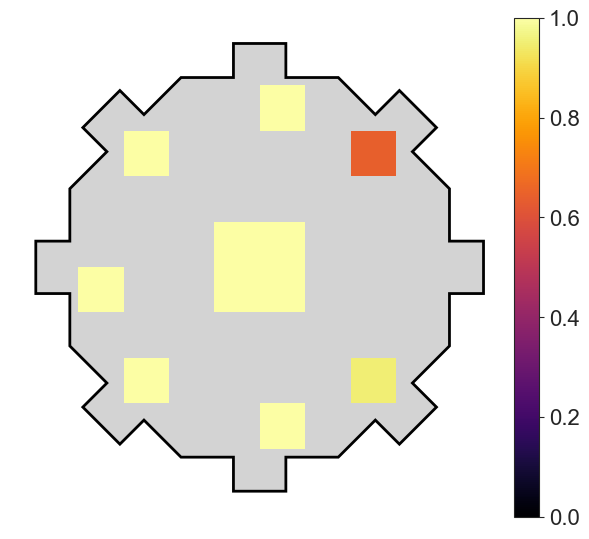

In [408]:
heatmap_phigh.plot_heatmap_phigh(probabilities, n_rows=10, n_cols=10, difference=False)

### Heatmap Low seen first

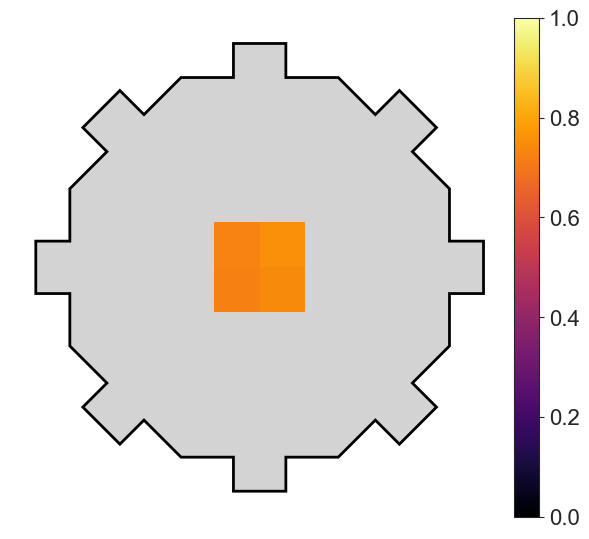

In [416]:
heatmap_phigh.plot_heatmap_phigh(probabilities, n_rows=10, n_cols=10, difference=False)

### Heatmap NOT filtered by first seen

In [374]:
(trial_list_vis_filtered,
  trial_list_vis_and_choice_filtered) = heatmap_phigh.filter_pipeline_p_high_first_seen_wall_no_filtering_vis(trial_lists,
                                                                                              num_players,
                                                                                              first_visible_wall_index,
                                                                                              chosen_wall_index)

In [375]:
# binning params
n_rows, n_cols = 10, 10
x_min, x_max = -20, 20
y_min, y_max = -20, 20
grid_width = (x_max - x_min) / n_cols
grid_height = (y_max - y_min) / n_rows

# initialise bin counts grid, choice grid
bins_dict_wall_seen = np.zeros((n_rows, n_cols))
bins_dict_wall_seen_wall_chosen = np.zeros((n_rows, n_cols))

In [376]:
# filtered for trials where player saw specified first-seen wall
trial_lists_denominator = trial_list_vis_filtered[player_id]
# filter for trials where player additionally chose specified chosen wall
trial_lists_numerator = trial_list_vis_and_choice_filtered[player_id]

In [377]:
# across each trial list for this player ID
for trial_list_index, trial_list in enumerate(trial_lists_denominator):

    # across each trial in the trial list
    for trial_index, trial in enumerate(trial_list):
        
        # get slice onset position (denominator)
        x_val, y_val = get_indices.get_player_slice_onset_loc(trial, player_id=player_id)

        # bin position
        x_bin = int((x_val - x_min) / grid_width)
        y_bin = int((y_val - y_min) / grid_height)

        # increment denominator bin count
        bins_dict_wall_seen[y_bin,x_bin] += 1



# across each trial list for this player ID
for trial_list_index, trial_list in enumerate(trial_lists_numerator):
    
    # across each trial in the filtered list
    for trial_index, trial in enumerate(trial_list):
        # get slice onset position (numerator)
        x_val, y_val = get_indices.get_player_slice_onset_loc(trial, player_id=player_id)

        # bin position
        x_bin = int((x_val - x_min) / grid_width)
        y_bin = int((y_val - y_min) / grid_height)

        # increment numerator bin count
        bins_dict_wall_seen_wall_chosen[y_bin,x_bin] += 1

print(f"Done for player {player_id}, counts in numerator index (3,0): {bins_dict_wall_seen_wall_chosen[6,0]} ")

Done for player 0, counts in numerator index (3,0): 0.0 


In [378]:
# element-wise division of numerator and denominator arrays, with handling for division by zero
pH_by_bin_high = np.divide(
    bins_dict_wall_seen_wall_chosen, bins_dict_wall_seen,
    out=np.zeros_like(bins_dict_wall_seen_wall_chosen, dtype=float),
    # boolean array to mask division for only non-zero denominator entries
    where=bins_dict_wall_seen > 0
)

# filter out bins with fewer than x trials
pH_by_bin_high[bins_dict_wall_seen <= 10] = np.nan
probabilities = pH_by_bin_high

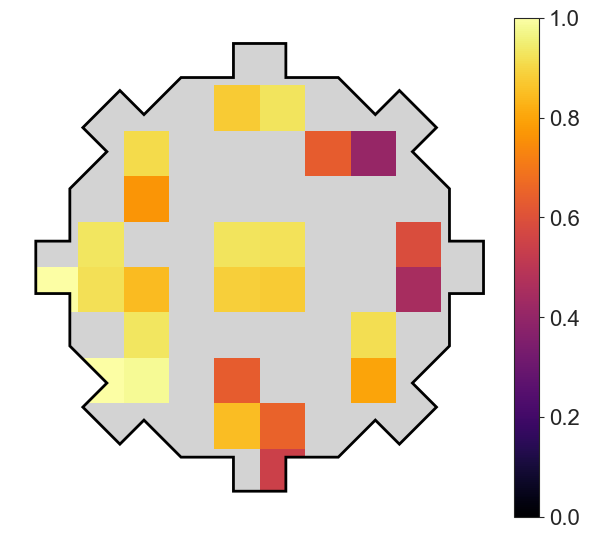

In [379]:
heatmap_phigh.plot_heatmap_phigh(probabilities, n_rows=10, n_cols=10, difference=False)

## Heatmaps by step penalty

In [346]:
trial_lists = trial_lists_solo
num_players = 1
player_id = 0
first_visible_wall_index = 1
chosen_wall_index = 0  # high wall
window_size = 1

In [347]:
(trial_list_low_vis_filtered,
  trial_list_low_vis_and_choice_filtered) = filter_pipeline_p_high_first_seen_wall(trial_lists,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index,
                                                                        5)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[0. 1. 0. 1. 1. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0.
 0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 1. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0.
 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0. 1. 1. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 1. 1.
 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1.
 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0.
 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0.
 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1. 0. 0.
 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1.
 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 

IndexError: index 0 is out of bounds for axis 1 with size 0

### Low first visible

11
step penalty: 0.00010704048327170312 


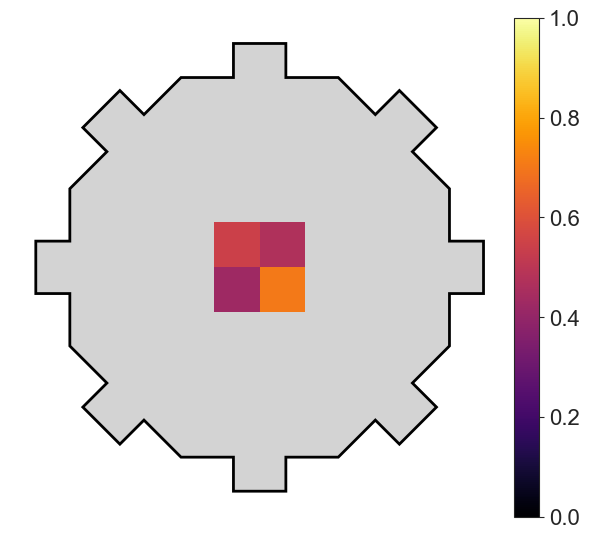

4
step penalty: 0.00016555322508793324 


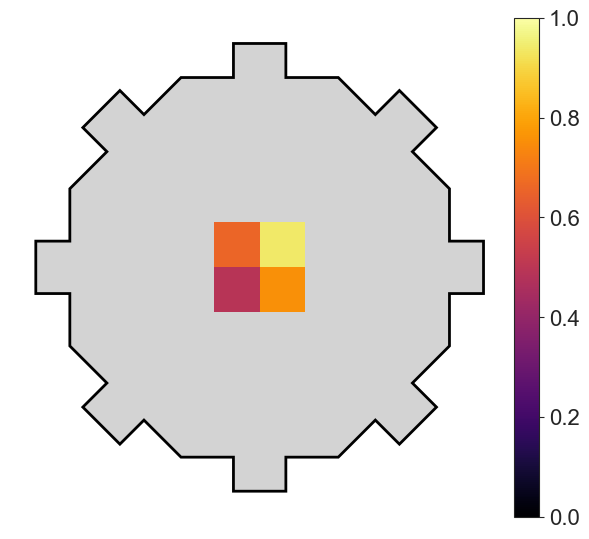

15
step penalty: 0.00025852452381514013 


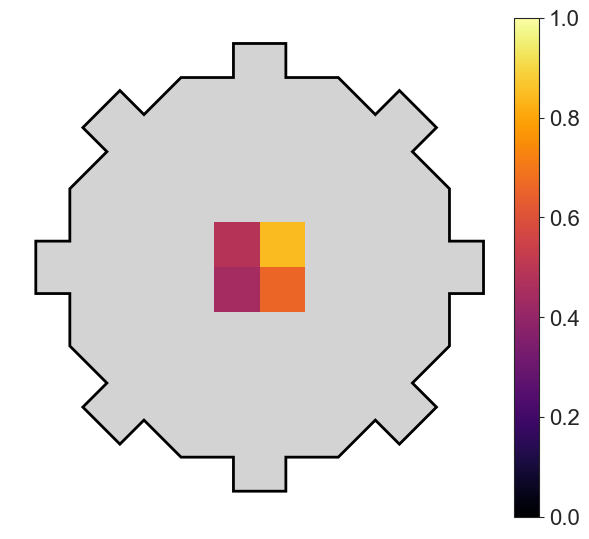

0
step penalty: 0.0003268012951593846 


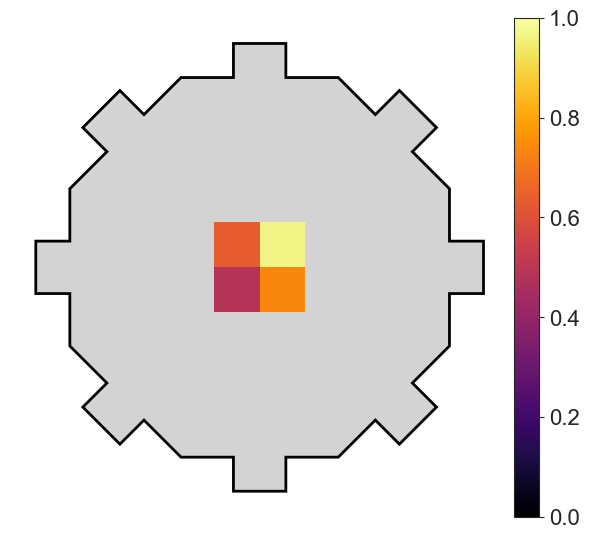

2
step penalty: 0.00034668066655285656 


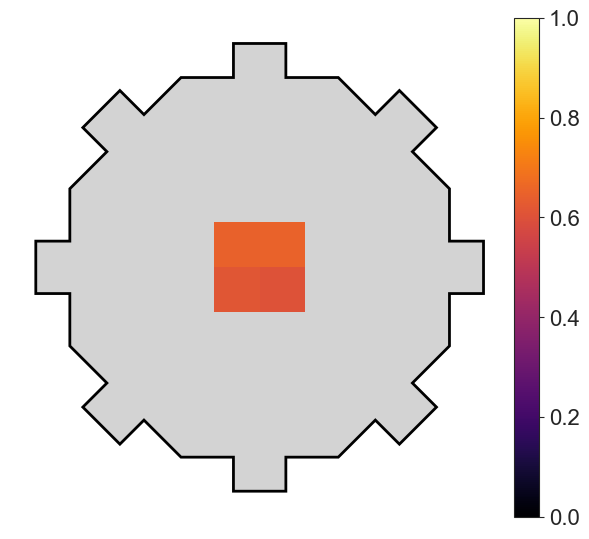

7
step penalty: 0.0005263549974188209 


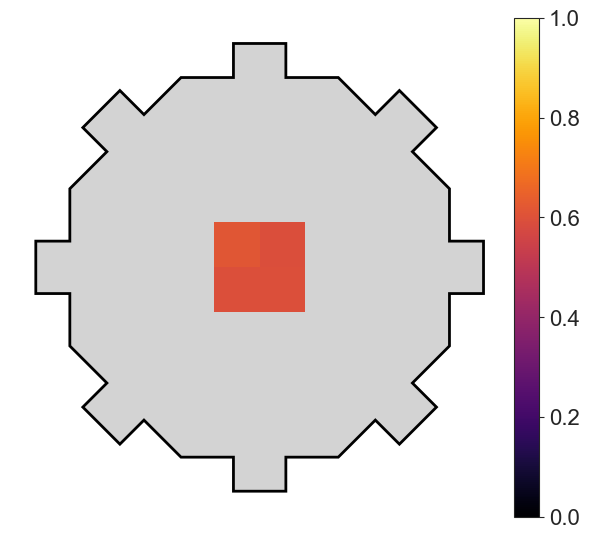

5
step penalty: 0.0005469489260576665 


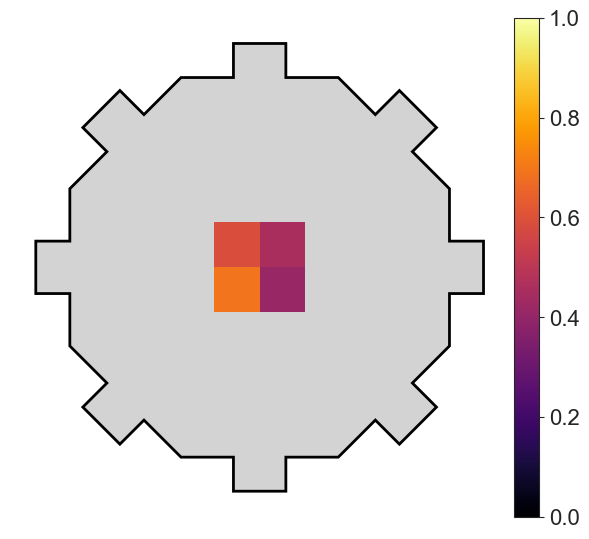

14
step penalty: 0.0005638919537886977 


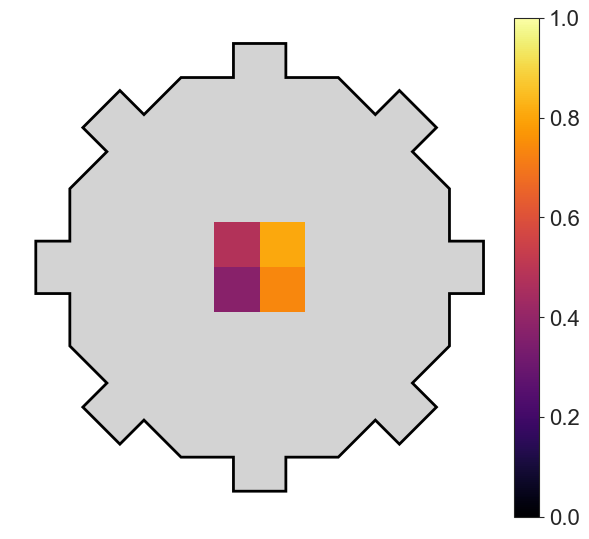

12
step penalty: 0.0006257125060074031 


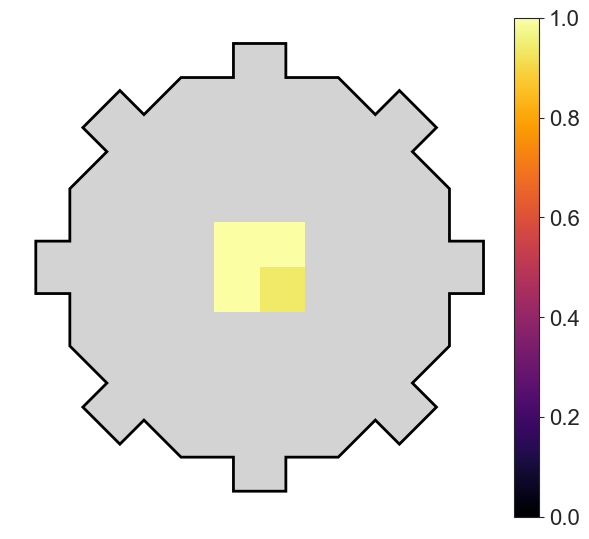

9
step penalty: 0.0007660744013264775 


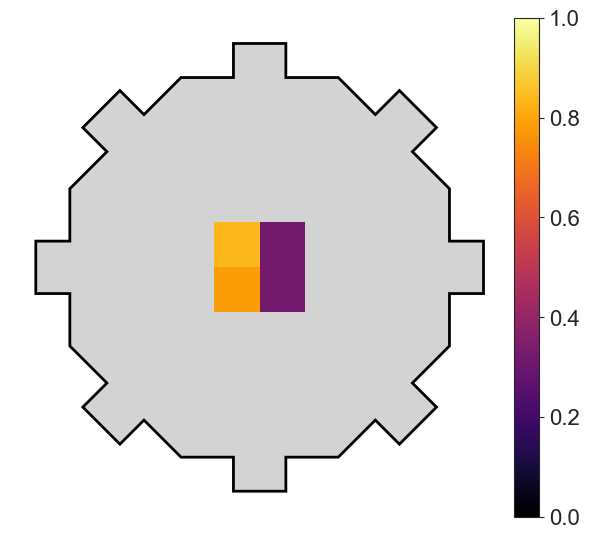

1
step penalty: 0.0008764611557126045 


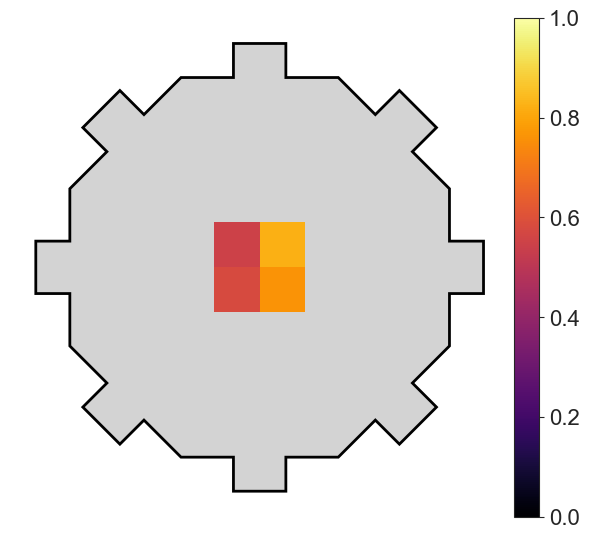

13
step penalty: 0.0009679252980276942 


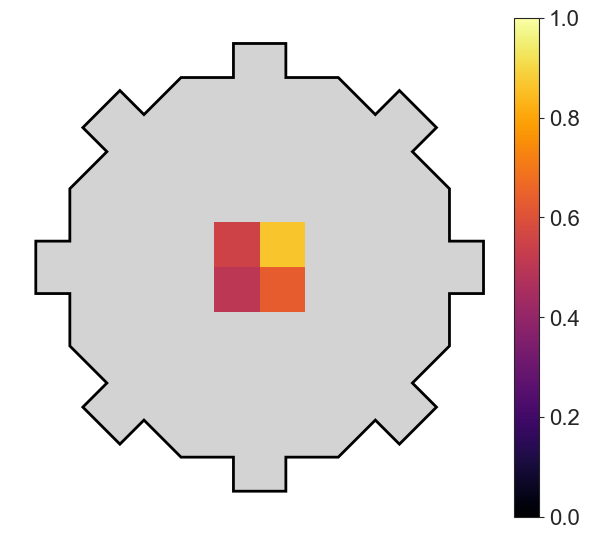

3
step penalty: 0.001046280493028462 


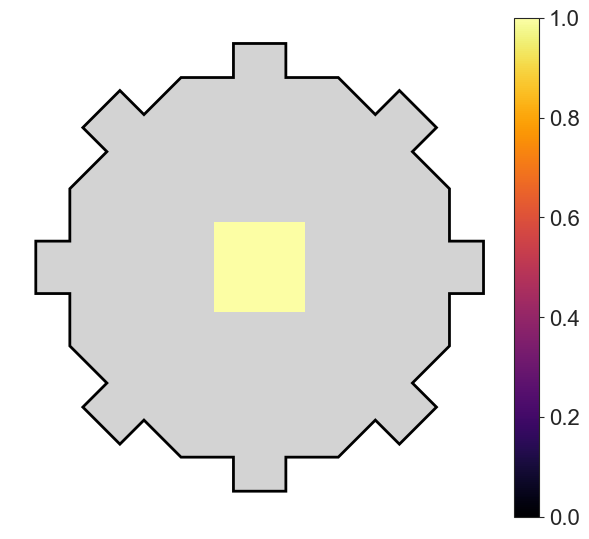

16
step penalty: 0.0011016197968274355 


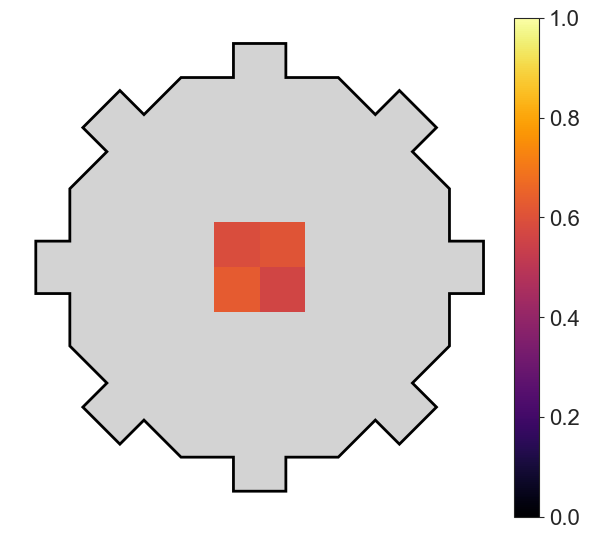

10
step penalty: 0.001118514221161604 


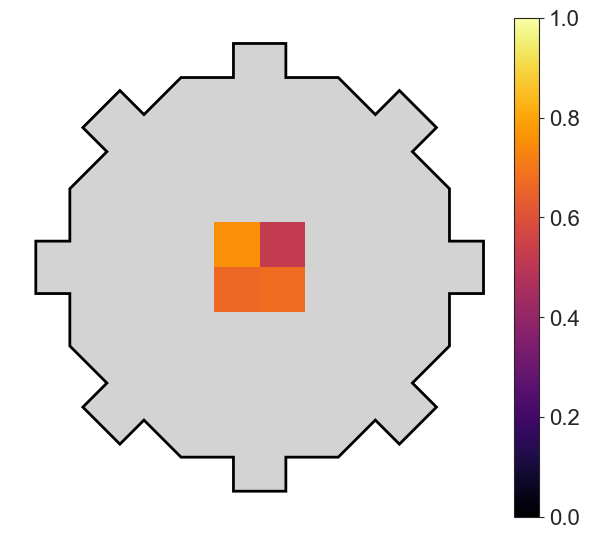

6
step penalty: 0.0011898450320586562 


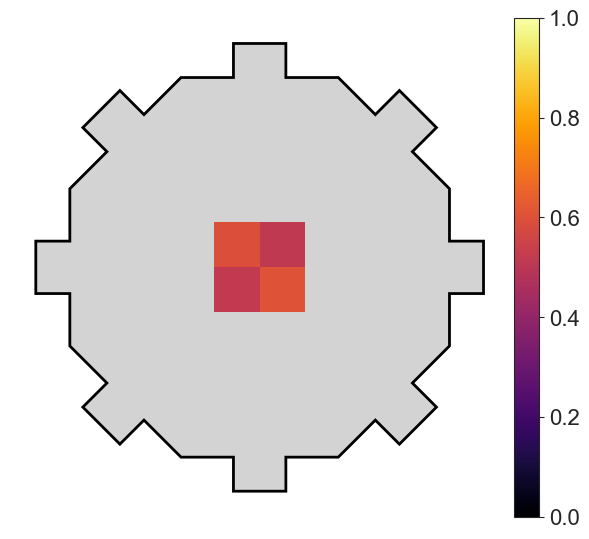

8
step penalty: 0.001218418125063181 


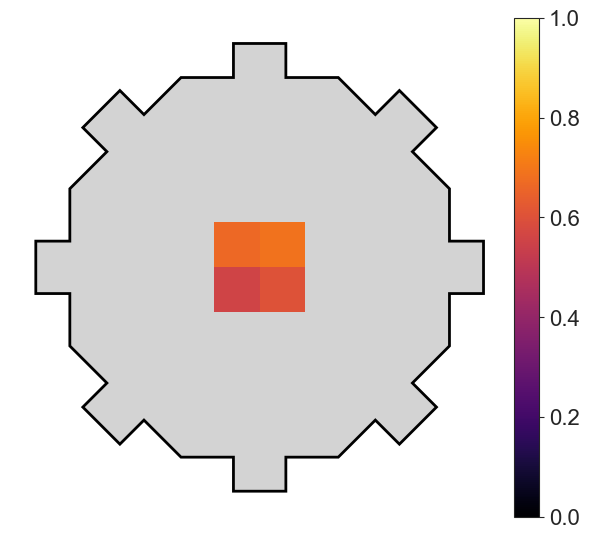

In [ ]:
num_i = len(trial_list_low_vis_filtered[0])

# Sort indices by step penalty size (ascending)
sorted_indices = np.argsort(step_penalties)

for idx in sorted_indices:
    i = idx
    print(i)
    # binning params
    n_rows, n_cols = 10, 10
    x_min, x_max = -20, 20
    y_min, y_max = -20, 20
    grid_width = (x_max - x_min) / n_cols
    grid_height = (y_max - y_min) / n_rows

    # initialise bin counts grid, choice grid
    bins_dict_wall_seen = np.zeros((n_rows, n_cols))
    bins_dict_wall_seen_wall_chosen = np.zeros((n_rows, n_cols))

    # across player ID 1 or 2
    for player_id in range(num_players):
        
        # filtered for trials where player saw specified first-seen wall
        trial_list_denominator = trial_list_low_vis_filtered[player_id][i]
        # filter for trials where player additionally chose specified chosen wall
        trial_list_numerator = trial_list_low_vis_and_choice_filtered[player_id][i]

        
        # across each trial in the trial list
        for trial_index, trial in enumerate(trial_list_denominator):
            
            # get slice onset position (denominator)
            x_val, y_val = get_indices.get_player_slice_onset_loc(trial, player_id=player_id)

            # bin position
            x_bin = int((x_val - x_min) / grid_width)
            y_bin = int((y_val - y_min) / grid_height)

            # increment denominator bin count
            bins_dict_wall_seen[y_bin,x_bin] += 1

        
        # across each trial in the filtered list
        for trial_index, trial in enumerate(trial_list_numerator):
            # get slice onset position (numerator)
            x_val, y_val = get_indices.get_player_slice_onset_loc(trial, player_id=player_id)

            # bin position
            x_bin = int((x_val - x_min) / grid_width)
            y_bin = int((y_val - y_min) / grid_height)

            # increment numerator bin count
            bins_dict_wall_seen_wall_chosen[y_bin,x_bin] += 1

    print(f"step penalty: {step_penalties[i]} ")

    # element-wise division of numerator and denominator arrays, with handling for division by zero
    pH_by_bin_low_solo = np.divide(
        bins_dict_wall_seen_wall_chosen, bins_dict_wall_seen,
        out=np.zeros_like(bins_dict_wall_seen_wall_chosen, dtype=float),
        # boolean array to mask division for only non-zero denominator entries
        where=bins_dict_wall_seen > 0
    )

    # filter out bins with fewer than x trials
    pH_by_bin_low_solo[bins_dict_wall_seen <= 10] = np.nan
    probabilities = pH_by_bin_low_solo

    # plot on the subplot
    heatmap_phigh.plot_heatmap_phigh(probabilities, n_rows=10, n_cols=10, difference=False)


### High first visible

In [103]:
trial_lists = trial_lists_solo
num_players = 1
player_id = 0
first_visible_wall_index = 0
chosen_wall_index = 0  # high wall
window_size = 1

In [104]:
(trial_list_high_vis_filtered,
  trial_list_high_vis_and_choice_filtered) = filter_pipeline_p_high_first_seen_wall(trial_lists,
                                                                        num_players,
                                                                        first_visible_wall_index,
                                                                        chosen_wall_index,
                                                                        window_size)

filter_trials_one_wall_becomes_visible_first - given_wall_first_visible_session array:
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1.
 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0.
 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1.
 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1.
 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 1.
 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0.
 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0.
 1. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0.
 1. 1. 1. 0. 0. 0. 1. 1. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 1. 1. 0. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 

11
step penalty: 0.00010704048327170312 


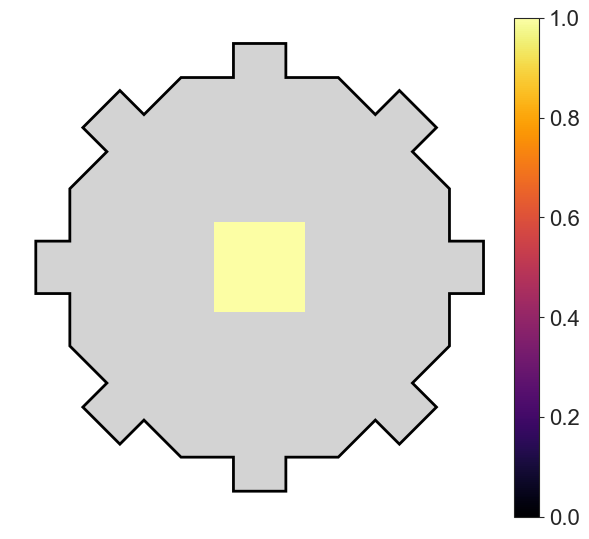

4
step penalty: 0.00016555322508793324 


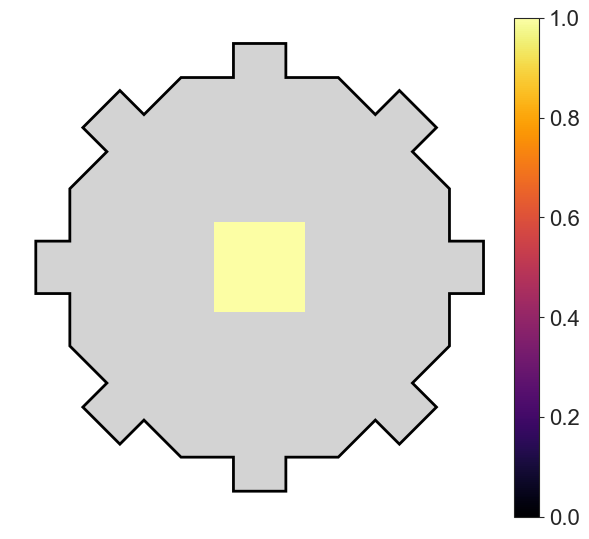

0
step penalty: 0.0003268012951593846 


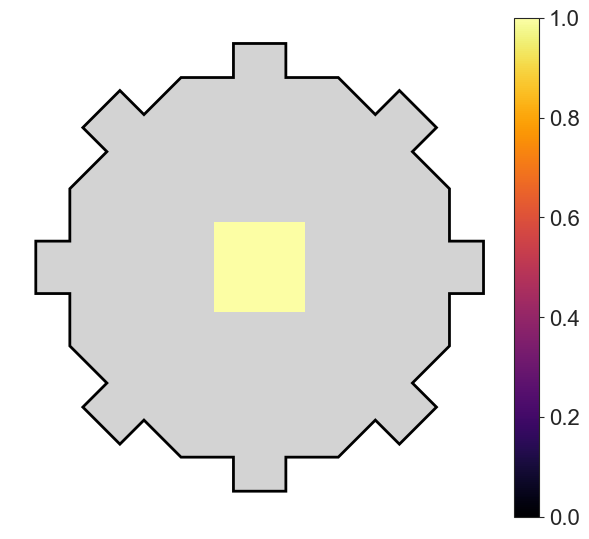

2
step penalty: 0.00034668066655285656 


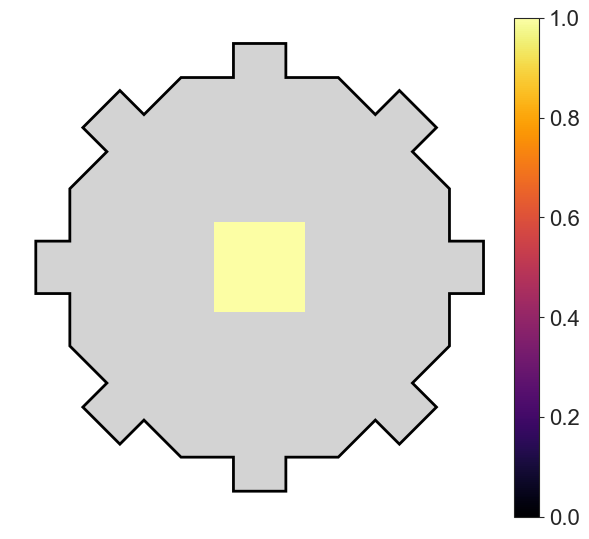

7
step penalty: 0.0005263549974188209 


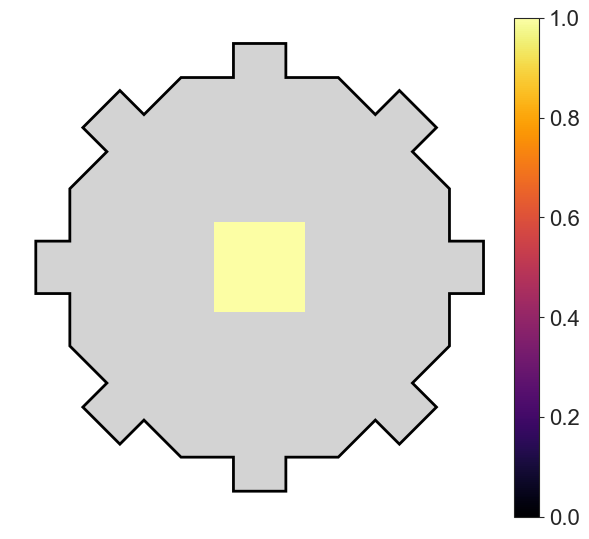

5
step penalty: 0.0005469489260576665 


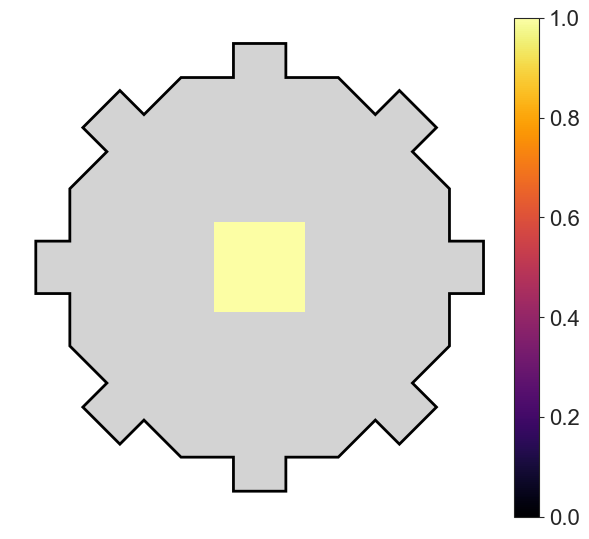

12
step penalty: 0.0006257125060074031 


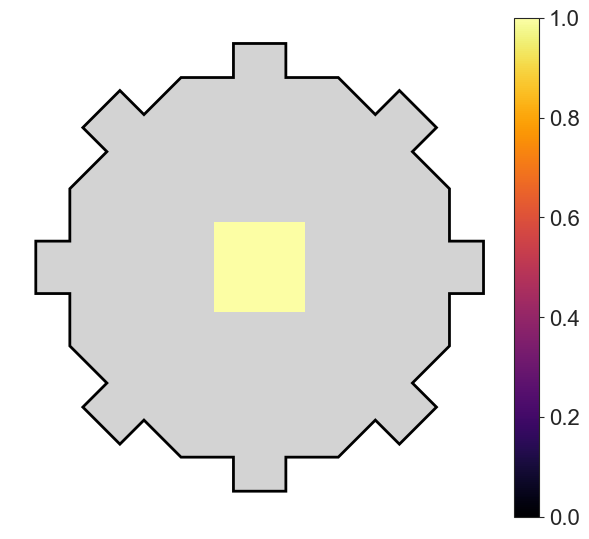

9
step penalty: 0.0007660744013264775 


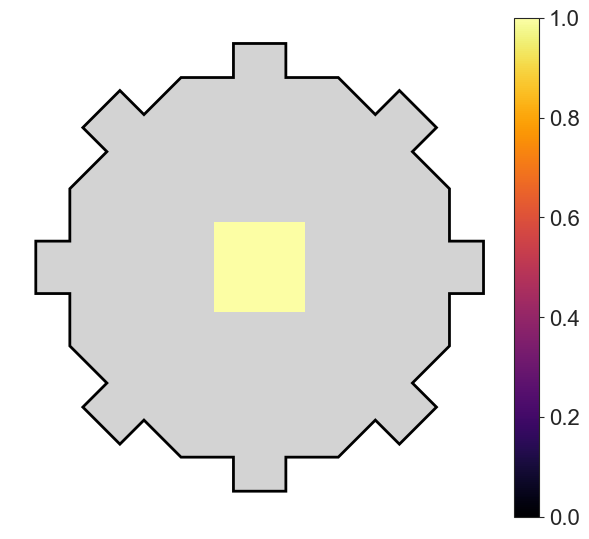

1
step penalty: 0.0008764611557126045 


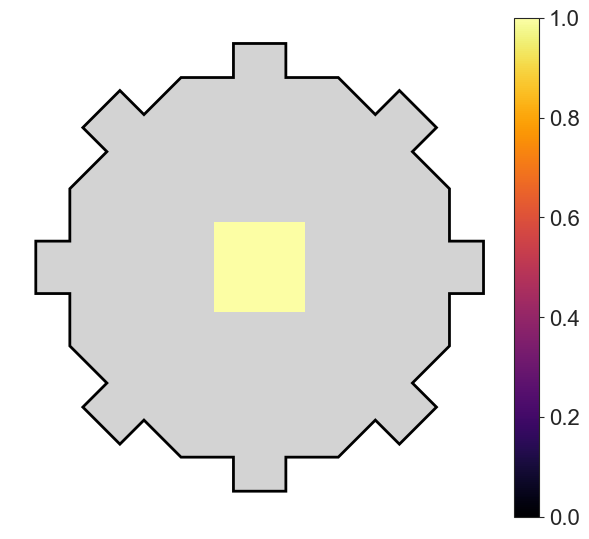

13
step penalty: 0.0009679252980276942 


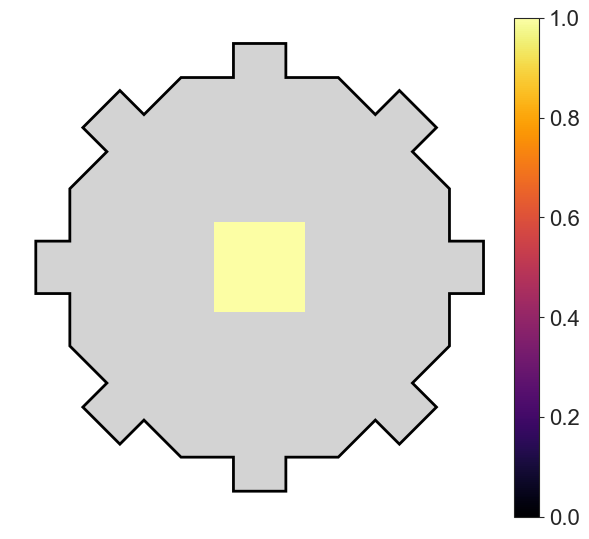

3
step penalty: 0.001046280493028462 


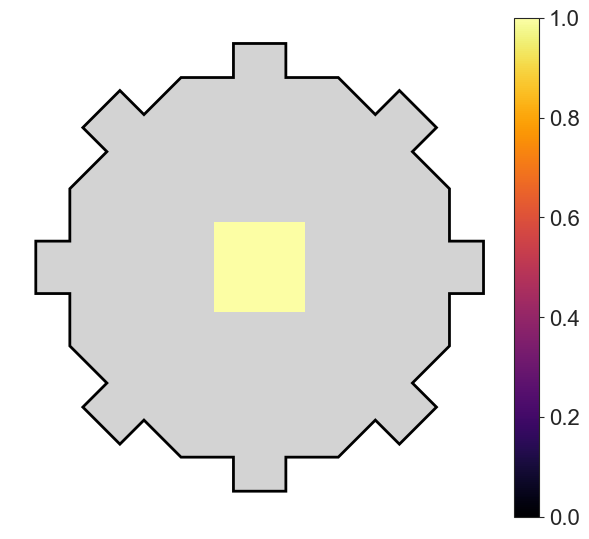

10
step penalty: 0.001118514221161604 


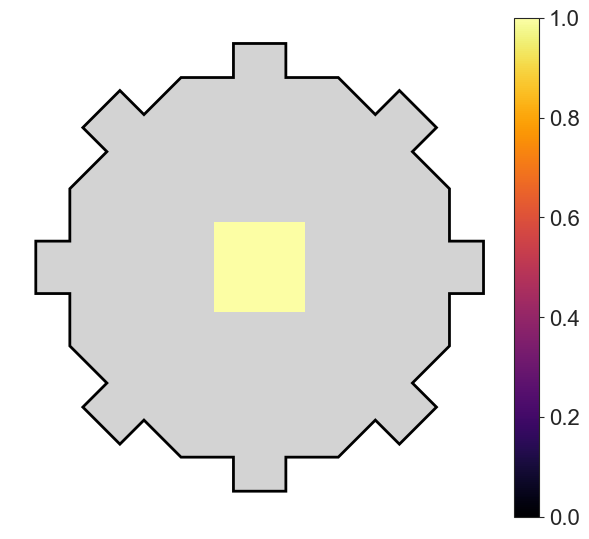

6
step penalty: 0.0011898450320586562 


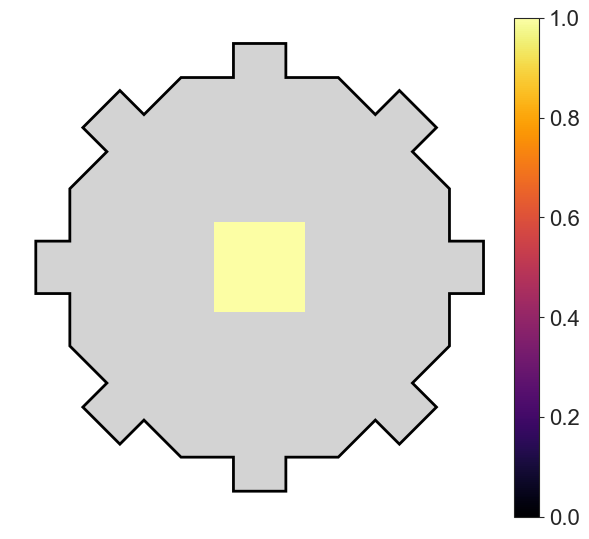

8
step penalty: 0.001218418125063181 


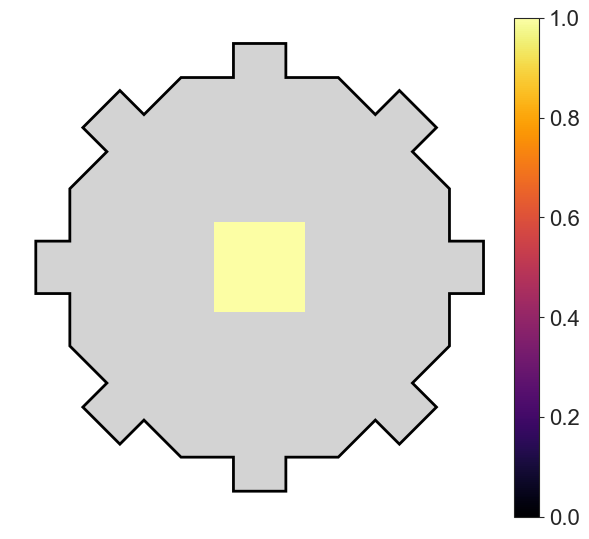

In [105]:
num_i = len(trial_list_high_vis_filtered[0])

# Sort indices by step penalty size (ascending)
sorted_indices = np.argsort(step_penalties)

for idx in sorted_indices:
    i = idx
    print(i)
    # binning params
    n_rows, n_cols = 10, 10
    x_min, x_max = -20, 20
    y_min, y_max = -20, 20
    grid_width = (x_max - x_min) / n_cols
    grid_height = (y_max - y_min) / n_rows

    # initialise bin counts grid, choice grid
    bins_dict_wall_seen = np.zeros((n_rows, n_cols))
    bins_dict_wall_seen_wall_chosen = np.zeros((n_rows, n_cols))

    # across player ID 1 or 2
    for player_id in range(num_players):
        
        # filtered for trials where player saw specified first-seen wall
        trial_list_denominator = trial_list_high_vis_filtered[player_id][i]
        # filter for trials where player additionally chose specified chosen wall
        trial_list_numerator = trial_list_high_vis_and_choice_filtered[player_id][i]

        
        # across each trial in the trial list
        for trial_index, trial in enumerate(trial_list_denominator):
            
            # get slice onset position (denominator)
            x_val, y_val = get_indices.get_player_slice_onset_loc(trial, player_id=player_id)

            # bin position
            x_bin = int((x_val - x_min) / grid_width)
            y_bin = int((y_val - y_min) / grid_height)

            # increment denominator bin count
            bins_dict_wall_seen[y_bin,x_bin] += 1

        
        # across each trial in the filtered list
        for trial_index, trial in enumerate(trial_list_numerator):
            # get slice onset position (numerator)
            x_val, y_val = get_indices.get_player_slice_onset_loc(trial, player_id=player_id)

            # bin position
            x_bin = int((x_val - x_min) / grid_width)
            y_bin = int((y_val - y_min) / grid_height)

            # increment numerator bin count
            bins_dict_wall_seen_wall_chosen[y_bin,x_bin] += 1

    print(f"step penalty: {step_penalties[i]} ")

    # element-wise division of numerator and denominator arrays, with handling for division by zero
    pH_by_bin_high_solo = np.divide(
        bins_dict_wall_seen_wall_chosen, bins_dict_wall_seen,
        out=np.zeros_like(bins_dict_wall_seen_wall_chosen, dtype=float),
        # boolean array to mask division for only non-zero denominator entries
        where=bins_dict_wall_seen > 0
    )

    # filter out bins with fewer than x trials
    pH_by_bin_high_solo[bins_dict_wall_seen <= 10] = np.nan
    probabilities = pH_by_bin_high_solo

    # plot on the subplot
    heatmap_phigh.plot_heatmap_phigh(probabilities, n_rows=10, n_cols=10, difference=False)


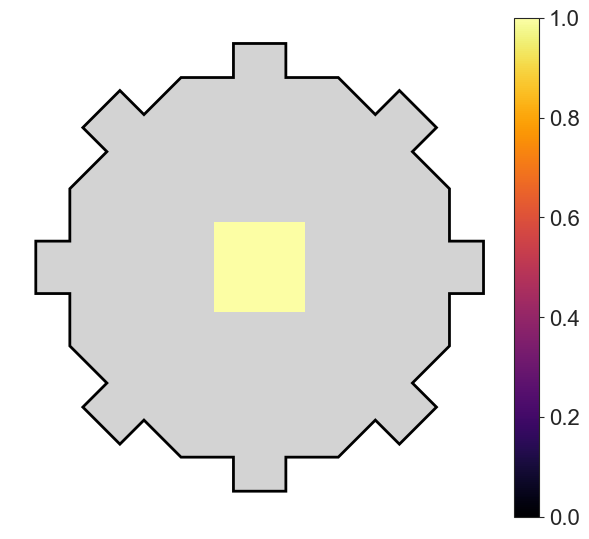

In [322]:
heatmap_phigh.plot_heatmap_phigh(probabilities, n_rows=10, n_cols=10, difference=False)